#1. Configuration, Imports, and Setup

In [ ]:
ds_name = "ml_latest_small"  #"ml_latest_small" # "lfm360k" #"ml_latest_small" #"ml_latest_small" #"ml_latest_small"
# Replace underscore with a hyphen
ds_name_n = ds_name.replace('_', '-')

use_precomputed = "Yes"
data_aug_with_rationale = "no"
flag_usePrecomputedAttack = "No"
attack_direction = 'promote'
llm_model = "llama3" #openai #llama3 #sentence_transformer"
attackName = 'original' #original # 'emotional' ,'neighbor' 'chain' , 'trigger'
NUM_USERS   = 120  # Evaluate on 10 users for demonstration

ratiosList = [0.1, 0.4]
neighborList = [5, 15]

ratio = ratiosList[0]
n = neighborList[1]

if attackName == 'emotional':
  attack_type = f"final_text_phase1_{int(ratio*100)}p_{attack_direction}_emotional"
elif attackName == 'neighbor':
  attack_type = f"final_text_phase1_{int(ratio*100)}p_{attack_direction}_neighbor{n}"
elif attackName == 'chain':
  attack_type = f"final_text_phase1_{int(ratio*100)}p_{attack_direction}_chain{n}"
elif attackName == 'trigger':
  attack_type = f"final_text_phase1_{int(ratio*100)}p_{attack_direction}_trigger{n}"
else:
  attack_type = ""

print(ds_name_n)
print(attack_type)



ml-latest-small



In [ ]:
import os

api_key = ""
os.environ["OPENAI_API_KEY"] = api_key

In [ ]:
!pip install openai==0.27.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.1/70.1 kB 1.8 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.61.1
    Uninstalling openai-1.61.1:
      Successfully uninstalled openai-1.61.1


In [ ]:
import requests
import pandas as pd
import ast
import openai

def download_csv(url, csv_file_name):
    """
    Download a CSV file from a URL and save it locally.

    Parameters:
    url (str): The URL to download the file from.
    csv_file_name (str): The local filename to save the downloaded file.

    Returns:
    bool: True if download succeeds, False otherwise.
    """
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(csv_file_name, "wb") as file:
            for chunk in response.iter_content(chunk_size=128):
                file.write(chunk)
        print(f"{csv_file_name} downloaded successfully.")
        return True
    print(f"Failed to download the file. Status code: {response.status_code}")
    return False

# Function to load a CSV file (compressed or uncompressed)
def load_csv_file(file_path):
    """
    Load a CSV file, handling both compressed (.csv.gz) and uncompressed (.csv) formats.

    Parameters:
    - file_path (str): Path to the CSV file.

    Returns:
    - pd.DataFrame: Loaded DataFrame.
    """
    if file_path.endswith('.csv.gz'):
        return pd.read_csv(file_path, compression='gzip')
    elif file_path.endswith('.csv'):
        return pd.read_csv(file_path)
    else:
        raise ValueError(f"Unsupported file format: {file_path}")

def load_data_ml():
    """
    Download and load datasets for ratings, items, and tags, merging tags into items.

    Returns:
    tuple: DataFrames for ratings, items, tags, and items with merged tags.
    """
    urls = {
        "ratings": "https://raw.githubusercontent.com/yasdel/RecSys_Datasets/e3a18487525d3ae8ec19b39959c1a881c383e1a8/ml_latest/df_ratings_ml-latest-small.csv",
        "items": "https://raw.githubusercontent.com/yasdel/RecSys_Datasets/e3a18487525d3ae8ec19b39959c1a881c383e1a8/ml_latest/df_item_ml-latest-small.csv",
        "tags": "https://raw.githubusercontent.com/yasdel/RecSys_Datasets/21484da12f01263fc0194d12c63d796628f84137/ml_latest/df_tags_ml-latest-small.csv"
    }
    files = {key: f"df_{key}_ml-latest-small.csv" for key in urls}

    if all(download_csv(urls[key], files[key]) for key in urls):
        df_ratings = pd.read_csv(files["ratings"], names=['userId', 'itemId', 'rating', 'timestamp'], header=0, low_memory=False)
        df_items = pd.read_csv(files["items"], low_memory=False)
        df_tags = pd.read_csv(files["tags"], low_memory=False)

        for df, col in [(df_ratings, 'userId'), (df_ratings, 'itemId'), (df_items, 'itemId'), (df_tags, 'itemId'), (df_tags, 'userId')]:
            df[col] = df[col].astype(int)

        tags_grouped = df_tags.groupby('itemId')['tag'].apply(list).reset_index()
        df_items_merged = pd.merge(df_items, tags_grouped, on='itemId', how='left')
        df_items_merged['tag'] = df_items_merged['tag'].apply(lambda x: x if isinstance(x, list) else [])

        print("Datasets loaded successfully.")
        return df_ratings, df_items_merged, df_tags

    print("Failed to download one or more datasets.")
    return None, None, None, None

def load_data_lastfm(n=10):
    """
    Loads the LFM-360K dataset from GitHub, downloads if needed.
    Then converts 'plays' into a rating [0..n] using the formula:
        rating(u,i) = n * F(playcount_u_i),
    where F(playcount_u_i) is the empirical CDF of that item’s
    playcount among the user’s listened items.

    Returns:
        df_ratings (DataFrame): columns [userId, itemId, rating]
        df_items   (DataFrame): columns [itemId, artist, tags]
    """
    url = "https://raw.githubusercontent.com/yasdel/RecSys_Datasets/main/lfm-360K/lastFM360k_trg_user_40000_trg_Artist_4000.csv"
    out_file = "lastFM360k_trg_user_40000_trg_Artist_4000.csv"

    success = download_csv(url, out_file)
    if not success:
        return None, None

    # Load
    df = pd.read_csv(out_file, low_memory=False, index_col = 0)
    display(df)
    # Rename columns so we can unify them with typical 'itemId', 'rating'
    df.rename(columns={'artistId': 'itemId', 'plays': 'playcount'}, inplace=True)

    # Construct a ratings DataFrame
    df_ratings = df[['userId', 'itemId', 'playcount']].copy()

    # === Compute the user-specific CDF-based rating ===
    # We group by user, compute the rank of each playcount among that user's items
    # so rating = n * ( rank / total_items_in_user_profile ).
    # We do rank(method='min') for tie handling, you can also do 'dense' if you prefer.

    df_ratings['rank_in_user'] = df_ratings.groupby('userId')['playcount'] \
                                           .rank(method='min', ascending=True)

    # Number of items each user has
    df_ratings['count_in_user'] = df_ratings.groupby('userId')['playcount'] \
                                            .transform('count')

    # Empirical CDF: fraction of items that have playcount <= current playcount
    # We'll do (rank_in_user / count_in_user).
    # Then multiply by n to get a [0..n] rating.
    df_ratings['rating'] = (df_ratings['rank_in_user'] / df_ratings['count_in_user']) * n

    # Now we only keep userId, itemId, rating
    df_ratings = df_ratings[['userId', 'itemId', 'rating']].copy()

    # Construct an items DataFrame
    df_items = df[['itemId', 'artist', 'tags']].drop_duplicates().copy()

    # Convert 'tags' from string to list if needed
    df_items['tags'] = df_items['tags'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
    )

    print("Last.fm dataset loaded and playcounts converted to rating scale [0..{}].".format(n))
    return df_ratings, df_items

def print_statistics(data):
    """
    Print dataset statistics including total interactions, unique users, items, and interaction ratios.

    Parameters:
    data (pd.DataFrame): DataFrame with 'userId' and 'itemId' columns.
    """
    display(data)
    total_interactions = data.shape[0]
    unique_users = data['userId'].nunique()
    unique_items = data['itemId'].nunique()

    print("--------------------------")
    print("The Dataset Overview:")
    print(f" - Total Interactions: {total_interactions}")
    print(f" - |U|: {unique_users}")
    print(f" - |I|: {unique_items}")
    print(f" - |R|/|U|: {total_interactions / unique_users:.2f}")
    print(f" - |R|/|I|: {total_interactions / unique_items:.2f}")
    print(f" - |R|/(|U|*|I|): {total_interactions / (unique_users * unique_items):.10f}")
    print("--------------------------")

def apply_interaction_limits(data, min_interactions, max_interactions, user_col, item_col):
    """
    Filter users based on interaction limits.

    Parameters:
    data (pd.DataFrame): DataFrame with interactions.
    min_interactions (int): Minimum number of interactions per user.
    max_interactions (int): Maximum number of interactions per user.
    user_col (str): Column name for users.
    item_col (str): Column name for items.

    Returns:
    pd.DataFrame: Filtered DataFrame.
    """
    interaction_counts = data[user_col].value_counts()
    users_to_keep = interaction_counts[(interaction_counts >= min_interactions) & (interaction_counts <= max_interactions)].index
    return data[data[user_col].isin(users_to_keep)]

display("Original Dataset Statistics:")



# Example: Download and load datasets
#df_ratings, df_items, df_tags = load_datasets()
#print_statistics(df_ratings)


# Main logic:
if ds_name == "ml_latest_small":
    df_ratings, df_items, df_tags = load_data_ml()  # returns three DFs for ML
    display(df_ratings.head())
    display(df_items.head())
    print_statistics(df_ratings)
    # Load the file from the local directory
    if data_aug_with_rationale.lower == "no":
      fileName = "enriched_descriptions_dataset_ml_latest_small_gpt-4o-mini_with_rationale_No.csv.gz"
    else:
      fileName = "enriched_descriptions_dataset_ml_latest_small_gpt-4o-mini_with_rationale_Yes.csv.gz"
    print(f'{fileName} loaded ... from dataset {ds_name}')
    df_items =  pd.read_csv("https://github.com/yasdel/GenRecSys-LLM-DataAugmentation/raw/main/Data/" + fileName, compression='gzip')
elif ds_name == "lfm360k":
    df_ratings, df_items = load_data_lastfm(n=10)       # returns two DFs for Last.fm
    if data_aug_with_rationale.lower == "no":
      fileName = "enriched_desc_ds_lfm360k_gpt-4o-mini_with_rationale_No.csv.gz"
    else:
      fileName = "enriched_desc_ds_lfm360k_gpt-4o-mini_with_rationale_Yes.csv.gz"
    print(f'{fileName} loaded ... from dataset {ds_name}')
    df_items =  pd.read_csv("https://github.com/yasdel/GenRecSys-LLM-DataAugmentation/raw/main/Data/" + fileName, compression='gzip')
    display(df_ratings.head())
    display(df_items.head())
    print_statistics(df_ratings)
else:
    raise ValueError("Unknown dataset_flag specified.")


# Check if 'tag' exists, then rename to 'tags'
if 'tags' in df_items.columns:
    df_items.rename(columns={'tags': 'tag'}, inplace=True)
    display(df_items.head())

# Example: Apply interaction limits if datasets are loaded
if ds_name == "ml_latest_small" and df_ratings is not None:
    MIN_INTERACTIONS, MAX_INTERACTIONS = 20, 100
    df_ratings_filtered = apply_interaction_limits(df_ratings, MIN_INTERACTIONS, MAX_INTERACTIONS, 'userId', 'itemId')

    display("Filtered Dataset Statistics:")
    print_statistics(df_ratings_filtered)

    sampled_item_ids = df_ratings_filtered['itemId'].unique()
    df_items_sampled = df_items[df_items['itemId'].isin(sampled_item_ids)]

    display("Sampled items with tags:")
    display(df_items_sampled.head())


'Original Dataset Statistics:'

df_ratings_ml-latest-small.csv downloaded successfully.
df_items_ml-latest-small.csv downloaded successfully.
df_tags_ml-latest-small.csv downloaded successfully.
Datasets loaded successfully.


,userId,itemId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,itemId,title,genres,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[pixar, pixar, fun]"
1,2,Jumanji (1995),Adventure|Children|Fantasy,"[fantasy, magic board game, Robin Williams, game]"
2,3,Grumpier Old Men (1995),Comedy|Romance,"[moldy, old]"
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,[]
4,5,Father of the Bride Part II (1995),Comedy,"[pregnancy, remake]"


,userId,itemId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


...

'Filtered Dataset Statistics:'

,userId,itemId,rating,timestamp
232,2,318,3.0,1445714835
233,2,333,4.0,1445715029
234,2,1704,4.5,1445715228
235,2,3578,4.0,1445714885
236,2,6874,4.0,1445714952
...,...,...,...,...
99529,609,892,3.0,847221080
99530,609,1056,3.0,847221080
99531,609,1059,3.0,847221054
99532,609,1150,4.0,847221054


--------------------------
The Dataset Overview:
 - Total Interactions: 16823
 - |U|: 365
 - |I|: 3079
 - |R|/|U|: 46.09
 - |R|/|I|: 5.46
 - |R|/(|U|*|I|): 0.0149692793
--------------------------


'Sampled items with tags:'

,itemId,title,genres,tag,enriched_description
0,19,Ace Ventura: When Nature Calls (1995),Comedy,[],"In the uproarious sequel ""Ace Ventura: When Na..."
1,42,Dead Presidents (1995),Action|Crime|Drama,[],"""Dead Presidents"" is a gripping 1995 film that..."
2,41,Richard III (1995),Drama|War,['Shakespeare'],"""Richard III"" (1995), directed by Richard Lonc..."
3,23,Assassins (1995),Action|Crime|Thriller,[],"In the heart-pounding action thriller ""Assassi..."
4,5,Father of the Bride Part II (1995),Comedy,"['pregnancy', 'remake']","In the delightful sequel ""Father of the Bride ..."


In [ ]:
import pandas as pd
import requests
from google.colab import files
from io import BytesIO
import gzip

if ds_name == "ml_latest_small" and attack_direction in ["promote"]:
  # GitHub raw URL of the dataset
  url = "https://github.com/yasdel/Poison-RAG-Plus/raw/main/AttackData/Augmentation_Attack_Data/augmented_items_ml_latest_small_promote_sample_size_10percent.csv.gz"
elif ds_name == "ml_latest_small" and attack_direction in ["demote"]:
  # GitHub raw URL of the dataset
  url = "https://github.com/yasdel/Poison-RAG-Plus/raw/main/AttackData/Augmentation_Attack_Data/augmented_items_ml_latest_small_demote_sample_size_10percent.csv.gz"


# Download the file
response = requests.get(url)
if response.status_code == 200:
    with gzip.open(BytesIO(response.content), 'rt', encoding='utf-8') as f:
        df_items = pd.read_csv(f)
else:
    print(f"Failed to download file. HTTP Status Code: {response.status_code}")

# Display the first few rows
display(df_items.head())

print(f'Attacked Item IDS')
attacked_item_ids_list = df_items.loc[
    df_items[f'phase1_{attack_direction}_applied'] == True,
    'itemId'
].unique()

print(attacked_item_ids_list)

,itemId,title,genres,tag,enriched_description,pop_class,sim_items_200,sim_items_200_class_based,phase1_10p_promote_emotional,phase1_10p_promote_neighbor5,...,final_text_phase1_10p_promote_neighbor15,final_text_phase1_10p_promote_chain15,final_text_phase1_10p_promote_trigger15,final_text_phase1_40p_promote_emotional,final_text_phase1_40p_promote_neighbor5,final_text_phase1_40p_promote_chain5,final_text_phase1_40p_promote_trigger5,final_text_phase1_40p_promote_neighbor15,final_text_phase1_40p_promote_chain15,final_text_phase1_40p_promote_trigger15
0,7,Sabrina (1995),Comedy|Romance,['remake'],**Sabrina (1995)** is a delightful romantic co...,0,"[915, 360, 6899, 345, 2155, 295, 68, 287, 1549...","{0: [186, 500, 555, 597, 1197, 1569, 1777, 229...",NaN,NaN,...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...
1,20,Money Train (1995),Action|Comedy|Crime|Drama|Thriller,[],**Money Train (1995)** is a thrilling blend of...,1,"[1604, 5454, 124859, 3537, 2391, 3384, 2344, 4...","{0: [1, 21, 172, 296, 333, 434, 778, 1073, 122...",NaN,NaN,...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...
2,36,Dead Man Walking (1995),Crime|Drama,"['death penalty', 'Nun']",**Dead Man Walking (1995)** is a poignant and ...,0,"[726, 7883, 81, 54787, 4160, 336, 1114, 3258, ...","{0: [151, 253, 282, 288, 377, 587, 1246, 1923,...",NaN,NaN,...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...
3,17,Sense and Sensibility (1995),Drama|Romance,['Jane Austen'],**Sense and Sensibility (1995)** is a beautifu...,0,"[7669, 28, 26958, 40629, 70521, 2027, 46976, 1...","{0: [34, 236, 261, 357, 497, 500, 509, 1674, 2...",NaN,NaN,...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...
4,3,Grumpier Old Men (1995),Comedy|Romance,"['moldy', 'old']",**Grumpier Old Men (1995)** is a delightful se...,0,"[3450, 1179, 184349, 1929, 100083, 3258, 1473,...","{0: [357, 410, 1278, 1721, 2003, 2324, 2407, 4...",NaN,NaN,...,**Grumpier Old Men (1995)** is a delightful se...,**Grumpier Old Men (1995)** is a delightful se...,**Grumpier Old Men (1995)** is a delightful se...,**Grumpier Old Men (1995)** is a delightful se...,**Grumpier Old Men (1995)** is a delightful se...,**Grumpier Old Men (1995)** is a delightful se...,**Grump

Attacked Item IDS
[    27     74    116    446    639    731    828    918   1066   1140
   1605   1629   1730   1998   2482   2747   2851   2896   3296   4228
   4863   5804   5841   5988   6238   6731   7255   7888   7899   8604
   8605  36535  43936  65350  74685 162600 174053 190215]


In [ ]:
!pip install requests pandas

import pandas as pd
import requests
import gzip
import io

# ----------------------------------------------------------------------------
# Helper function to fetch a CSV (gzipped) from GitHub by filename
# ----------------------------------------------------------------------------
def fetch_csv_from_github(base_url, filename):
    """
    Given a base GitHub 'raw' URL (without trailing slash)
    and a filename ending in .gz, this function downloads
    the file, decompresses it, and returns a Pandas DataFrame.
    """
    url = f"{base_url}/{filename}"
    r = requests.get(url)
    r.raise_for_status()
    # Decompress .gz into a CSV buffer, then read into DataFrame
    with gzip.open(io.BytesIO(r.content), 'rt', encoding='utf-8') as f:
        df = pd.read_csv(f)
    return df

# ----------------------------------------------------------------------------
# Helper function to load and concatenate all "partX" files for one scenario
# ----------------------------------------------------------------------------
def load_attack_parts(base_url, prefix, csv_parts_list=[1,2,3]):
    """
    prefix examples:
       openai_final_text_phase1_10p_promote_emotional
       openai_final_text_phase1_40p_promote_chain15
       etc.

    We expect part1, part2, part3 files, each named:
       {prefix}_part1.csv.gz
       {prefix}_part2.csv.gz
       {prefix}_part3.csv.gz

    We concatenate them into one DataFrame and rename its
    'embeddings' column to prefix (for final merging).
    """
    dfs = []
    for i in csv_parts_list:
        fname = f"{prefix}_part{i}.csv.gz"
        df_part = fetch_csv_from_github(base_url, fname)
        dfs.append(df_part)

    combined = pd.concat(dfs, ignore_index=True)

    # We expect columns ['itemId', 'embeddings']
    if "itemId" not in combined.columns or "embeddings" not in combined.columns:
        raise ValueError(
            f"Could not find expected columns ['itemId','embeddings'] in {prefix}_partX!"
        )

    # Rename 'embeddings' => prefix
    combined = combined[["itemId", "embeddings"]].rename(columns={"embeddings": prefix})
    return combined

# ----------------------------------------------------------------------------
# Main logic
# ----------------------------------------------------------------------------

# Your GitHub "raw" URL (no trailing slash) for the folder containing .csv.gz files
base_url = (
    "https://raw.githubusercontent.com/"
    "yasdel/Poison-RAG-Plus/main/"
    f"AttackData/Embeddings_from_Augmentation_Attack_Data/{ds_name_n}"
)

if ds_name == "ml_latest_small" and llm_model.lower() == "llama3" and attack_direction in ["promote", "demote"]:

    # The “final_text” files vary by these attacks and percentages
    attacks = [
        "emotional",
        "neighbor5", "neighbor15",
        "chain5", "chain15",
        "trigger5", "trigger15"
    ]
    percentages = ["10p", "40p"]

    final_df = None

    # Loop over all attack combos, load the 3 .csv.gz parts, merge into final_df
    for pct in percentages:
        for attack in attacks:
            prefix = f"llama_final_text_phase1_{pct}_{attack_direction}_{attack}"
            df_attack = load_attack_parts(base_url, prefix)

            # Merge on itemId
            if final_df is None:
                final_df = df_attack
            else:
                final_df = pd.merge(final_df, df_attack, on="itemId", how="inner")

    # ------------------------------------------------------------------------
    # Now handle the "openai_enriched_description_partX.csv.gz" files
    # ------------------------------------------------------------------------
    dfs_enriched = []
    for i in [1, 2, 3]:
        fname = f"llama_enriched_description_part{i}.csv.gz"
        df_enriched = fetch_csv_from_github(base_url, fname)
        dfs_enriched.append(df_enriched)

    # Concatenate the 3 parts
    df_enriched_all = pd.concat(dfs_enriched, ignore_index=True)

    # We expect ['itemId', 'embeddings']
    if "itemId" not in df_enriched_all.columns or "embeddings" not in df_enriched_all.columns:
        raise ValueError("Could not find ['itemId','embeddings'] in openai_enriched_description files!")

    # Rename 'embeddings' => 'openai_enriched_description'
    df_enriched_all = df_enriched_all[["itemId", "embeddings"]].rename(
        columns={"embeddings": "llama_enriched_description"}
    )

    # Merge with final_df using outer (so we keep all itemIds from final_df plus new ones)
    if final_df is None:
        final_df = df_enriched_all
    else:
        final_df = pd.merge(final_df, df_enriched_all, on="itemId", how="outer")

    print(final_df.head(10))  # quick peek

    # Save the result locally
    final_df.to_csv("combined_embeddings.csv", index=False)

    # Keep a copy for later use
    combined_df = final_df.copy()
    display(combined_df.head())
elif ds_name == "ml_latest_small" and llm_model.lower() == "openai" and attack_direction in ["promote", "demote"]:

    # The “final_text” files vary by these attacks and percentages
    attacks = [
        "emotional",
        "neighbor5", "neighbor15",
        "chain5", "chain15",
        "trigger5", "trigger15"
    ]
    percentages = ["10p", "40p"]

    final_df = None

    # Loop over all attack combos, load the 3 .csv.gz parts, merge into final_df
    for pct in percentages:
        for attack in attacks:
            prefix = f"openai_final_text_phase1_{pct}_{attack_direction}_{attack}"
            df_attack = load_attack_parts(base_url, prefix)

            # Merge on itemId
            if final_df is None:
                final_df = df_attack
            else:
                final_df = pd.merge(final_df, df_attack, on="itemId", how="inner")

    # ------------------------------------------------------------------------
    # Now handle the "openai_enriched_description_partX.csv.gz" files
    # ------------------------------------------------------------------------
    dfs_enriched = []
    for i in [1, 2, 3]:
        fname = f"openai_enriched_description_part{i}.csv.gz"
        df_enriched = fetch_csv_from_github(base_url, fname)
        dfs_enriched.append(df_enriched)

    # Concatenate the 3 parts
    df_enriched_all = pd.concat(dfs_enriched, ignore_index=True)

    # We expect ['itemId', 'embeddings']
    if "itemId" not in df_enriched_all.columns or "embeddings" not in df_enriched_all.columns:
        raise ValueError("Could not find ['itemId','embeddings'] in openai_enriched_description files!")

    # Rename 'embeddings' => 'openai_enriched_description'
    df_enriched_all = df_enriched_all[["itemId", "embeddings"]].rename(
        columns={"embeddings": "openai_enriched_description"}
    )

    # Merge with final_df using outer (so we keep all itemIds from final_df plus new ones)
    if final_df is None:
        final_df = df_enriched_all
    else:
        final_df = pd.merge(final_df, df_enriched_all, on="itemId", how="outer")

    print(final_df.head(10))  # quick peek

    # Save the result locally
    final_df.to_csv("combined_embeddings.csv", index=False)

    # Keep a copy for later use
    combined_df = final_df.copy()
    display(combined_df.head())

if ds_name == "ml_latest_small" and llm_model.lower() == "sentence_transformer" and attack_direction in ["promote", "demote"]:

    # The “final_text” files vary by these attacks and percentages
    attacks = [
        "emotional",
        "neighbor5", "neighbor15",
        "chain5", "chain15",
        "trigger5", "trigger15"
    ]
    percentages = ["10p", "40p"]

    final_df = None

    # Loop over all attack combos, load the 3 .csv.gz parts, merge into final_df
    for pct in percentages:
        for attack in attacks:
            prefix = f"st_final_text_phase1_{pct}_{attack_direction}_{attack}"
            df_attack = load_attack_parts(base_url, prefix, csv_parts_list=[1])

            # Merge on itemId
            if final_df is None:
                final_df = df_attack
            else:
                final_df = pd.merge(final_df, df_attack, on="itemId", how="inner")

    # ------------------------------------------------------------------------
    # Now handle the "openai_enriched_description_partX.csv.gz" files
    # ------------------------------------------------------------------------
    dfs_enriched = []
    for i in [1]:
        fname = f"st_enriched_description_part{i}.csv.gz"
        df_enriched = fetch_csv_from_github(base_url, fname)
        dfs_enriched.append(df_enriched)

    # Concatenate the 3 parts
    df_enriched_all = pd.concat(dfs_enriched, ignore_index=True)

    # We expect ['itemId', 'embeddings']
    if "itemId" not in df_enriched_all.columns or "embeddings" not in df_enriched_all.columns:
        raise ValueError("Could not find ['itemId','embeddings'] in st_enriched_description files!")

    # Rename 'embeddings' => 'openai_enriched_description'
    df_enriched_all = df_enriched_all[["itemId", "embeddings"]].rename(
        columns={"embeddings": "st_enriched_description"}
    )

    # Merge with final_df using outer (so we keep all itemIds from final_df plus new ones)
    if final_df is None:
        final_df = df_enriched_all
    else:
        final_df = pd.merge(final_df, df_enriched_all, on="itemId", how="outer")

    print(final_df.head(10))  # quick peek

    # Save the result locally
    final_df.to_csv("combined_embeddings.csv", index=False)

    # Keep a copy for later use
    combined_df = final_df.copy()
    display(combined_df.head())
else:
    print("The condition (ds_name, llm_model, attack_direction) does not match the required logic.")


   itemId      llama_final_text_phase1_10p_promote_emotional  \
0       1  0.403564453125 -0.708984375 1.0322265625 0.252...   
1       2  0.34326171875 -0.40869140625 0.0338134765625 -...   
2       3  0.9267578125 -0.84912109375 0.57861328125 -0.2...   
3       4  0.7060546875 -0.9482421875 0.1890869140625 -0....   
4       5  0.8310546875 -0.583984375 -0.05841064453125 0....   
5       6  0.9326171875 -1.060546875 0.2236328125 -0.1984...   
6       7  0.4072265625 -0.7998046875 0.939453125 -0.2976...   
7       9  0.09356689453125 -0.82275390625 0.093444824218...   
8      10  0.8330078125 -1.2314453125 0.962890625 -0.1674...   
9      11  0.268798828125 -0.0242156982421875 0.619628906...   

       llama_final_text_phase1_10p_promote_neighbor5  \
0  -0.3505859375 -0.49462890625 -0.150390625 0.04...   
1  0.43505859375 -0.87060546875 0.477783203125 -0...   
2  0.389404296875 -0.58203125 -0.1064453125 -0.56...   
3  0.556640625 -0.8515625 0.67578125 0.0256347656...   
4  0.8330078125

,itemId,llama_final_text_phase1_10p_promote_emotional,llama_final_text_phase1_10p_promote_neighbor5,llama_final_text_phase1_10p_promote_neighbor15,llama_final_text_phase1_10p_promote_chain5,llama_final_text_phase1_10p_promote_chain15,llama_final_text_phase1_10p_promote_trigger5,llama_final_text_phase1_10p_promote_trigger15,llama_final_text_phase1_40p_promote_emotional,llama_final_text_phase1_40p_promote_neighbor5,llama_final_text_phase1_40p_promote_neighbor15,llama_final_text_phase1_40p_promote_chain5,llama_final_text_phase1_40p_promote_chain15,llama_final_text_phase1_40p_promote_trigger5,llama_final_text_phase1_40p_promote_trigger15,llama_enriched_description
0,1,0.403564453125 -0.708984375 1.0322265625 0.252...,-0.3505859375 -0.49462890625 -0.150390625 0.04...,-0.3505859375 -0.49462890625 -0.150390625 0.04...,0.403564453125 -0.708984375 1.0322265625 0.252...,0.403564453125 -0.708984375 1.0322265625 0.252...,0.403564453125 -0.708984375 1.0322265625 0.252...,0.47119140625 -0.66845703125 0.132568359375 -0...,-0.3505859375 -0.49462890625 -0.150390625 0.04...,-0.3505859375 -0.49462890625 -0.150390625 0.04...,0.403564453125 -0.708984375 1.0322265625 0.252...,-0.17041015625 -0.2261962890625 0.11669921875 ...,-0.3505859375 -0.49462890625 -0.150390625 0.04...,-0.3505859375 -0.49462890625 -0.150390625 0.04...,0.666015625 -0.5166015625 0.28271484375 0.0308...,-0.3505859375 -0.49462890625 -0.150390625 0.04...
1,2,0.34326171875 -0.40869140625 0.0338134765625 -...,0.43505859375 -0.87060546875 0.477783203125 -0...,0.09356689453125 -0.82275390625 0.093444824218...,0.43505859375 -0.87060546875 0.477783203125 -0...,0.43505859375 -0.87060546875 0.477783203125 -0...,0.73974609375 -0.73681640625 0.218994140625 -0...,0.34326171875 -0.40869140625 0.0338134765625 -...,0.09356689453125 -0.82275390625 0.093444824218...,0.34326171875 -0.40869140625 0.0338134765625 -...,0.73974609375 -0.73681640625 0.218994140625 -0...,0.73974609375 -0.73681640625 0.218994140625 -0...,0.43505859375 -0.87060546875 0.477783203125 -0...,0.43505859375 -0.87060546875 0.477783203125 -0...,0.34326171875 -0.40869140625 0.0338134765625 -...,0.34326171875 -0.40869140625 0.0338134765625 -...
2,3,0.9267578125 -0.84912109375 0.57861328125 -0.2...,0.389404296875 -0.58203125 -0.1064453125 -0.56...,0.389404296875 -0.58203125 -0.1064453125 -0.56...,0.389404296875 -0.58203125 -0.1064453125 -0.56...,0.389404296875 -0.58203125 -0.1064453125 -0.56...,0.389404296875 -0.58203125 -0.1064453125 -0.56...,0.1734619140625 -0.75 0.050750732421875 0.2814...,0.389404296875 -0.58203125 -0.1064453125 -0.56...,0.409912109375 -1.1416015625 0.0570068359375 -...,0.409912109375 -1.1416015625 0.0570068359375 -...,0.409912109375 -1.1416015625 0.0570068359375 -...,0.389404296875 -0.58203125 -0.1064453125 -0.56...,0.389404296875 -0.58203125 -0.1064453125 -0.56...,0.1734619140625 -0.75 0.050750732421875 0.2814...,0.409912109375 -1.1416015625 0.0570068359375 -...
3,4,0.7060546875 -0.9482421875 0.1890869140625 -0....,0.556640625 -0.8515625 0.67578125 0.0256347656...,0.5703125 -1.21875 0.390869140625 -0.645019531...,0.556640625 -0.8515625 0.67578125 0.0256347656...,0.556640625 -0.8515625 0.67578125 0.0256347656...,0.81494140625 -0.77734375 0.5654296875 0.19995...,0.7060546875 -0.9482421875 0.1890869140625 -0....,0.5703125 -1.21875 0.390869140625 -0.645019531...,0.7060546875 -0.9482421875 0.1890869140625 -0....,0.81494140625 -0.77734375 0.5654296875 0.19995...,0.81494140625 -0.77734375 0.5654296875 0.19995...,0.556640625 -0.8515625 0.67578125 0.0256347656...,0.556640625 -0.8515625 0.67578125 0.0256347656...,0.7060546875 -0.9482421875 0.1890869140625 -0....,0.7060546875 -0.9482421875 0.1890869140625 -0....
4,5,0.8310546875 -0.583984375 -0.05841064453125 0....,0.8330078125 -1.2314453125 0.962890625 -0.1674...,0.8310546875 -0.583984375 -0.05841064453125 0....,-0.0906982421875 -0.413330078125 0.05651855468...,-0.0906982421875 -0.413330078125 0.05651855468...,0.8310546875 -0.583984375 -0.05841064453125 0....,-0.09069824

The condition (ds_name, llm_model, attack_direction) does not match the required logic.


In [ ]:
# Create a new DataFrame with only 'item_id' and the selected embedding column
selected_embedding_column = f'{llm_model}_{attack_type}'   #openai_phase1_10p_demote_emotional_part1
if llm_model == "sentence_transformer":
  selected_embedding_column = selected_embedding_column.replace('sentence_transformer', 'st')
elif llm_model == "llama3":
  selected_embedding_column = selected_embedding_column.replace('llama3', 'llama')
if attackName == "original":
  selected_embedding_column = f'{llm_model}_enriched_description'
  if llm_model == "sentence_transformer":
    selected_embedding_column = selected_embedding_column.replace('sentence_transformer', 'st')
  elif llm_model == "llama3":
    selected_embedding_column = selected_embedding_column.replace('llama3', 'llama')
print(selected_embedding_column)
embedding_df = combined_df[['itemId', selected_embedding_column]].copy()
embedding_df.rename(columns={selected_embedding_column: 'embeddings', 'item_id': 'itemId'}, inplace=True)
display(embedding_df.head())


# Assuming `df_items` is your DataFrame
#attacked_item_ids = embedding_df['itemId'].unique()
# Converting to a list (optional)
#attacked_item_ids_list = attacked_item_ids.tolist()
# Printing the result
#print(attacked_item_ids_list)
#print(len(attacked_item_ids_list))


llama_enriched_description


,itemId,embeddings
0,1,-0.3505859375 -0.49462890625 -0.150390625 0.04...
1,2,0.34326171875 -0.40869140625 0.0338134765625 -...
2,3,0.409912109375 -1.1416015625 0.0570068359375 -...
3,4,0.7060546875 -0.9482421875 0.1890869140625 -0....
4,5,0.8330078125 -1.2314453125 0.962890625 -0.1674...


In [ ]:
import pandas as pd
import requests
import os

def download_and_combine_embeddings(base_url, output_dir, filename_prefix, parts, output_filename):
    """
    Downloads multiple parts of embeddings from GitHub, combines them, and saves the result locally.

    Parameters:
        base_url (str): The base URL for downloading files.
        output_dir (str): Directory to save the downloaded files.
        filename_prefix (str): Common prefix for all parts of the filenames.
        parts (list): List of part numbers to download (e.g., ["part1", "part2", ...]).
        output_filename (str): Filename to save the combined DataFrame.

    Returns:
        pd.DataFrame: Combined DataFrame of all embeddings.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    combined_df = pd.DataFrame()

    for part in parts:
        file_url = f"{base_url}{filename_prefix}_{part}.csv.gz"
        local_file = os.path.join(output_dir, f"{filename_prefix}_{part}.csv.gz")

        # Download the file
        print(f"Downloading {file_url}...")
        response = requests.get(file_url, stream=True)
        if response.status_code == 200:
            with open(local_file, "wb") as file:
                for chunk in response.iter_content(chunk_size=1024):
                    file.write(chunk)
            print(f"{local_file} downloaded successfully.")
        else:
            print(f"Failed to download {file_url}. Status code: {response.status_code}")
            continue

        # Read the downloaded file into a DataFrame
        try:
            part_df = pd.read_csv(local_file, compression='gzip')
            combined_df = pd.concat([combined_df, part_df], ignore_index=True)
            print(f"{local_file} successfully read and combined.")
        except Exception as e:
            print(f"Error reading {local_file}: {e}")

    # Save the combined DataFrame
    combined_output_file = os.path.join(output_dir, output_filename)
    combined_df.to_csv(combined_output_file, index=False)
    print(f"Combined embeddings saved to {combined_output_file}.")

    return combined_df

# ===================================================
# Main Script
# ===================================================
#if __name__ == "__main__":
#    # Define constants
#    BASE_URL = "https://github.com/yasdel/GenRecSys-LLM-DataAugmentation/raw/main/Data/Embedding-with-rationale/ml-latest-small/openAI/"
#    OUTPUT_DIR = "downloaded_embeddings"
#    FILENAME_PREFIX = "openai_all_tag_20_embeddings"
#    PARTS = [f"part{i}" for i in range(1, 8)]  # "part1" to "part7"
#    OUTPUT_FILENAME = "combined_embeddings.csv"

    # Download, combine, and display the embeddings
#    embedding_df = download_and_combine_embeddings(BASE_URL, OUTPUT_DIR, FILENAME_PREFIX, PARTS, OUTPUT_FILENAME)

    # Display the combined DataFrame
#    print("\nCombined Embeddings:")
#    display(embedding_df.head())


# 2. Building the *RAG* Pipeline
## 2.1.   Retrieval stage (using embedding)

### 2.1.1 Use Embeddings








In [ ]:
import numpy as np
import pandas as pd
import random
from ast import literal_eval
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # for 3D plotting

################################
# Part 1: Data Prep (Proposing)
################################

def parse_embedding_string(emb_str):
    """
    Convert a string like '-0.0093 0.0012 ...' into a numpy float32 array.
    If emb_str is already a list/array, just convert to np.array.
    """
    if isinstance(emb_str, str):
        float_vals = [float(x) for x in emb_str.strip().split()]
        return np.array(float_vals, dtype=np.float32)
    elif isinstance(emb_str, (list, np.ndarray)):
        return np.array(emb_str, dtype=np.float32)
    else:
        raise ValueError("Unknown format for item embedding.")

def build_embedding_dict(embedding_df):
    """
    Build {itemId: np.array([...])} from 'embedding_df'
    which has columns ['itemId', 'embeddings'].
    """
    embedding_dict = {}
    for _, row in embedding_df.iterrows():
        item_id = row['itemId']
        emb_val = parse_embedding_string(row['embeddings'])
        embedding_dict[item_id] = emb_val
    return embedding_dict


### 2.1.2 Computing User Embedding-based Profiles

In [ ]:
#############################
# Part 2: User Embeddings
#############################

def compute_user_embedding_random(user_id, embedding_dict):
    """
    Returns a random embedding vector, ignoring actual user ratings.
    Useful as a baseline or fallback.
    """
    emb_dim = len(next(iter(embedding_dict.values())))
    return np.random.rand(emb_dim)

def compute_user_embedding_average(user_id, df_ratings, embedding_dict, min_rating_threshold=4.0):
    """
    Compute a user embedding by averaging embeddings of items rated >= min_rating_threshold.
    If no such items, fallback to a random vector of the same dimension.
    """
    # Subset user ratings
    user_ratings = df_ratings[df_ratings['userId'] == user_id]
    high_rated_items = user_ratings[user_ratings['rating'] >= min_rating_threshold]['itemId'].unique()

    # Collect item embeddings
    item_embs = []
    for item_id in high_rated_items:
        if item_id in embedding_dict:
            item_embs.append(embedding_dict[item_id])

    # Fallback if no embeddings found
    if len(item_embs) == 0:
        emb_dim = len(next(iter(embedding_dict.values())))
        return np.random.rand(emb_dim)

    # Average embedding
    return np.mean(item_embs, axis=0)

def compute_user_embedding_temporal(user_id, df_ratings, embedding_dict, alpha=0.001, min_rating_threshold=4.0):
    """
    Temporally-aware embedding:
      - For each item the user rated >= min_rating_threshold,
        we collect its embedding * a time-based weight.
      - Weight is higher for more recent items.
    """
    user_rows = df_ratings[df_ratings['userId'] == user_id]
    # Only keep items with rating >= threshold
    user_rows = user_rows[user_rows['rating'] >= min_rating_threshold]
    if user_rows.empty:
        # fallback random
        return compute_user_embedding_random(user_id, embedding_dict)

    # Average timestamp of this user
    mean_time = user_rows['timestamp'].mean()

    # Collect weighted embeddings
    weighted_embs = []
    weights = []
    for _, row in user_rows.iterrows():
        item_id = row['itemId']
        if item_id not in embedding_dict:
            continue

        t = row['timestamp']
        # Logistic-based weight
        w = 1.0 / (1.0 + np.exp(-alpha * (t - mean_time)))
        weighted_embs.append(embedding_dict[item_id] * w)
        weights.append(w)

    if len(weighted_embs) == 0:
        # fallback
        return compute_user_embedding_random(user_id, embedding_dict)

    # Weighted average
    sum_emb = np.sum(weighted_embs, axis=0)
    sum_w   = np.sum(weights)
    return sum_emb / sum_w

def compute_user_embedding(user_id, df_ratings, embedding_dict, method="temporal", min_rating_threshold=4.0):
    """
    Wrapper function.
    Depending on 'method', compute user embedding in different ways.
    """
    if method == "random":
        return compute_user_embedding_random(user_id, embedding_dict)
    elif method == 'average':
        return compute_user_embedding_average(user_id, df_ratings, embedding_dict)
    elif method == "temporal":
        return compute_user_embedding_temporal(user_id, df_ratings, embedding_dict,
                                               alpha=0.001,
                                               min_rating_threshold=min_rating_threshold)
    else:
        raise ValueError(f"Unknown method: {method}")


##2.1.3 LLM-based Retrieval with kNN and user-profile embeddings

In [ ]:
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.neighbors import NearestNeighbors

#########################
# Part 3: Retrieval
#########################

def build_item_matrix(embedding_dict):
    """
    Convert embedding_dict -> (item_matrix, item_ids).
    item_matrix shape: (num_items, emb_dim)
    """
    item_ids = list(embedding_dict.keys())
    item_matrix = np.array([embedding_dict[i] for i in item_ids], dtype='float32')
    return item_matrix, item_ids


def retrieve_top_N_items(user_emb, item_matrix, item_ids, N=5):
    """
    Uses scikit-learn's NearestNeighbors for retrieval with cosine distance.
    Imputes missing values using KNNImputer (n_neighbors=3) before fitting.
    Returns a list of (item_id, distance), sorted by ascending distance.
    """
    # 1) KNN-based imputation of NaN values in item_matrix and user_emb
    imputer = KNNImputer(n_neighbors=3)

    # Fit on the item_matrix (which can contain multiple items)
    item_matrix_imputed = imputer.fit_transform(item_matrix)

    # Transform user_emb (reshape to 2D first so imputer can handle a single row)
    user_emb_imputed = imputer.transform(user_emb.reshape(1, -1))[0]

    # 2) Fit NearestNeighbors on the imputed item_matrix
    nn = NearestNeighbors(n_neighbors=N, metric='cosine')
    nn.fit(item_matrix_imputed)

    # 3) Retrieve neighbors for user_emb_imputed
    distances, indices = nn.kneighbors([user_emb_imputed])

    # 4) Build and return sorted results [(item_id, distance), ...]
    results = [(item_ids[idx], distances[0][i]) for i, idx in enumerate(indices[0])]
    return sorted(results, key=lambda x: x[1])

#########################
# Part 4: Visualization
#########################

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

def visualize_embeddings_2d(user_embeddings_dict, embedding_dict, item_ids_subset):
    """
    Create three 2D scatter plots showing the user embeddings (random, average, temporal)
    and zoom in for the average and temporal embeddings.
    """
    # Extract item embeddings and labels for the selected items
    item_embs = []
    item_labels = []
    for iid in item_ids_subset:
        if iid in embedding_dict:
            item_embs.append(embedding_dict[iid])
            item_labels.append(str(iid))

    item_embs = np.array(item_embs)

    if item_embs.shape[1] < 2:
        print("Item embeddings have fewer than 2 dimensions; cannot plot in 2D.")
        return

    # Restrict to first two dimensions for plotting
    item_embs_2d = item_embs[:, :2]
    user_embs_2d = {method: emb[:2] for method, emb in user_embeddings_dict.items()}

    # Create 3 plots: Random, Average, Temporal + 1 Zoomed plot for Average & Temporal
    fig, axes = plt.subplots(1, 4, figsize=(24, 6), gridspec_kw={'width_ratios': [1, 1, 1, 1.5]})
    methods = list(user_embeddings_dict.keys())

    # Plot individual methods
    for i, method in enumerate(methods):
        ax = axes[i]
        user_emb = user_embs_2d[method]

        # Scatter plot of items
        ax.scatter(item_embs_2d[:, 0], item_embs_2d[:, 1], c='b', label='Items', alpha=0.7)
        for j, label in enumerate(item_labels):
            ax.text(item_embs_2d[j, 0], item_embs_2d[j, 1], f' {label}', fontsize=8, color='blue')

        # Plot user embedding
        ax.scatter(user_emb[0], user_emb[1], c='r', marker='X', s=150, label=f'User ({method})')
        ax.text(user_emb[0], user_emb[1], f' User', fontsize=10, color='red')

        # Titles and labels
        ax.set_title(f'User Embedding: {method}', fontsize=12)
        ax.set_xlabel('Dim 1')
        ax.set_ylabel('Dim 2')
        ax.legend(loc='best')

    # Plot Zoomed-in View for Average and Temporal
    ax_zoom = axes[3]
    zoom_methods = ['average', 'temporal']
    for method in zoom_methods:
        user_emb = user_embs_2d[method]
        ax_zoom.scatter(user_emb[0], user_emb[1], label=f'User ({method})', s=150, marker='X')
        ax_zoom.text(user_emb[0], user_emb[1], f' User ({method})', fontsize=10)

    # Add nearby item embeddings to zoomed plot
    zoom_threshold = 0.05  # Distance threshold for nearby items
    for method in zoom_methods:
        user_emb = user_embs_2d[method]
        distances = np.linalg.norm(item_embs_2d - user_emb, axis=1)
        nearby_items = item_embs_2d[distances < zoom_threshold]
        ax_zoom.scatter(nearby_items[:, 0], nearby_items[:, 1], label=f'Nearby Items ({method})', alpha=0.7)

    ax_zoom.set_title("Zoomed-In View (Average & Temporal)", fontsize=12)
    ax_zoom.set_xlabel('Dim 1')
    ax_zoom.set_ylabel('Dim 2')
    ax_zoom.legend(loc='best')

    plt.tight_layout()
    plt.savefig('myfig.pdf')
    plt.show()


### 2.1.4. Visualization and Demonstration

Randomly selected user IDs for testing: [495, 179]
Sampled 322 unique item IDs based on selected users.

=== User 495 ===
Random embedding (first 3 coords): [0.49502657 0.53194718 0.05898229]
Average embedding (first 3 coords): [ 0.3884605  -0.7312269   0.38004535]
Temporal embedding (first 3 coords): [ 0.3988553  -0.74655527  0.3732013 ]

Top-3 User Watched Movies:
  Big Short, The (2015) (Rating: 5.0)
  Social Network, The (2010) (Rating: 5.0)
  Best in Show (2000) (Rating: 5.0)

Top-5 Retrieval Results for Random Embedding:
  161 (Crimson Tide (1995)), dist=0.9859
  1247 (Graduate, The (1967)), dist=0.9868
  8917 (Team America: World Police (2004)), dist=0.9874
  141 (Birdcage, The (1996)), dist=0.9891
  8641 (Anchorman: The Legend of Ron Burgundy (2004)), dist=0.9900

Top-5 Retrieval Results for Average Embedding:
  5989 (Catch Me If You Can (2002)), dist=0.0429
  457 (Fugitive, The (1993)), dist=0.0525
  165 (Die Hard: With a Vengeance (1995)), dist=0.0575
  380 (True Lies (1994))

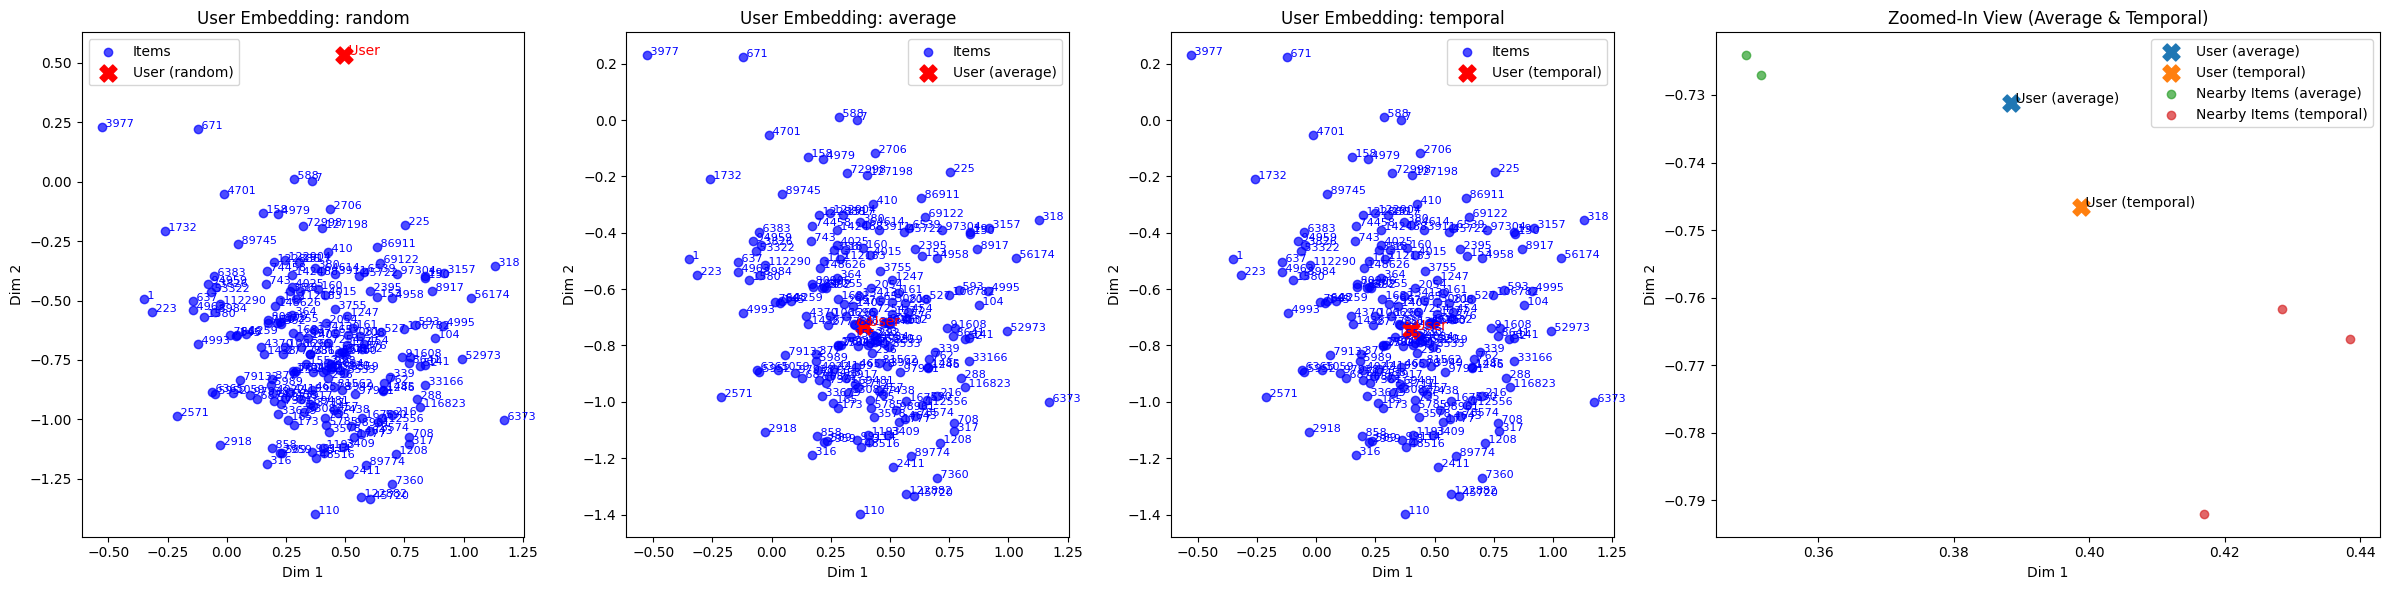


=== User 179 ===
Random embedding (first 3 coords): [0.6463547  0.7649842  0.90592157]
Average embedding (first 3 coords): [ 0.46159515 -0.7172224   0.33454242]
Temporal embedding (first 3 coords): [ 0.37961742 -0.6671578   0.33631244]

Top-3 User Watched Movies:
  Shawshank Redemption, The (1994) (Rating: 5.0)
  Babe (1995) (Rating: 5.0)
  Crimson Tide (1995) (Rating: 5.0)

Top-5 Retrieval Results for Random Embedding:
  8917 (Team America: World Police (2004)), dist=0.9583
  1517 (Austin Powers: International Man of Mystery (1997)), dist=0.9637
  2700 (South Park: Bigger, Longer and Uncut (1999)), dist=0.9648
  141 (Birdcage, The (1996)), dist=0.9662
  106696 (Frozen (2013)), dist=0.9666

Top-5 Retrieval Results for Average Embedding:
  5989 (Catch Me If You Can (2002)), dist=0.0431
  457 (Fugitive, The (1993)), dist=0.0453
  165 (Die Hard: With a Vengeance (1995)), dist=0.0515
  380 (True Lies (1994)), dist=0.0530
  9 (Sudden Death (1995)), dist=0.0579

Top-5 Retrieval Results for 

<ipython-input-10-b87a6cb82212>:63: RuntimeWarning: overflow encountered in exp
  w = 1.0 / (1.0 + np.exp(-alpha * (t - mean_time)))


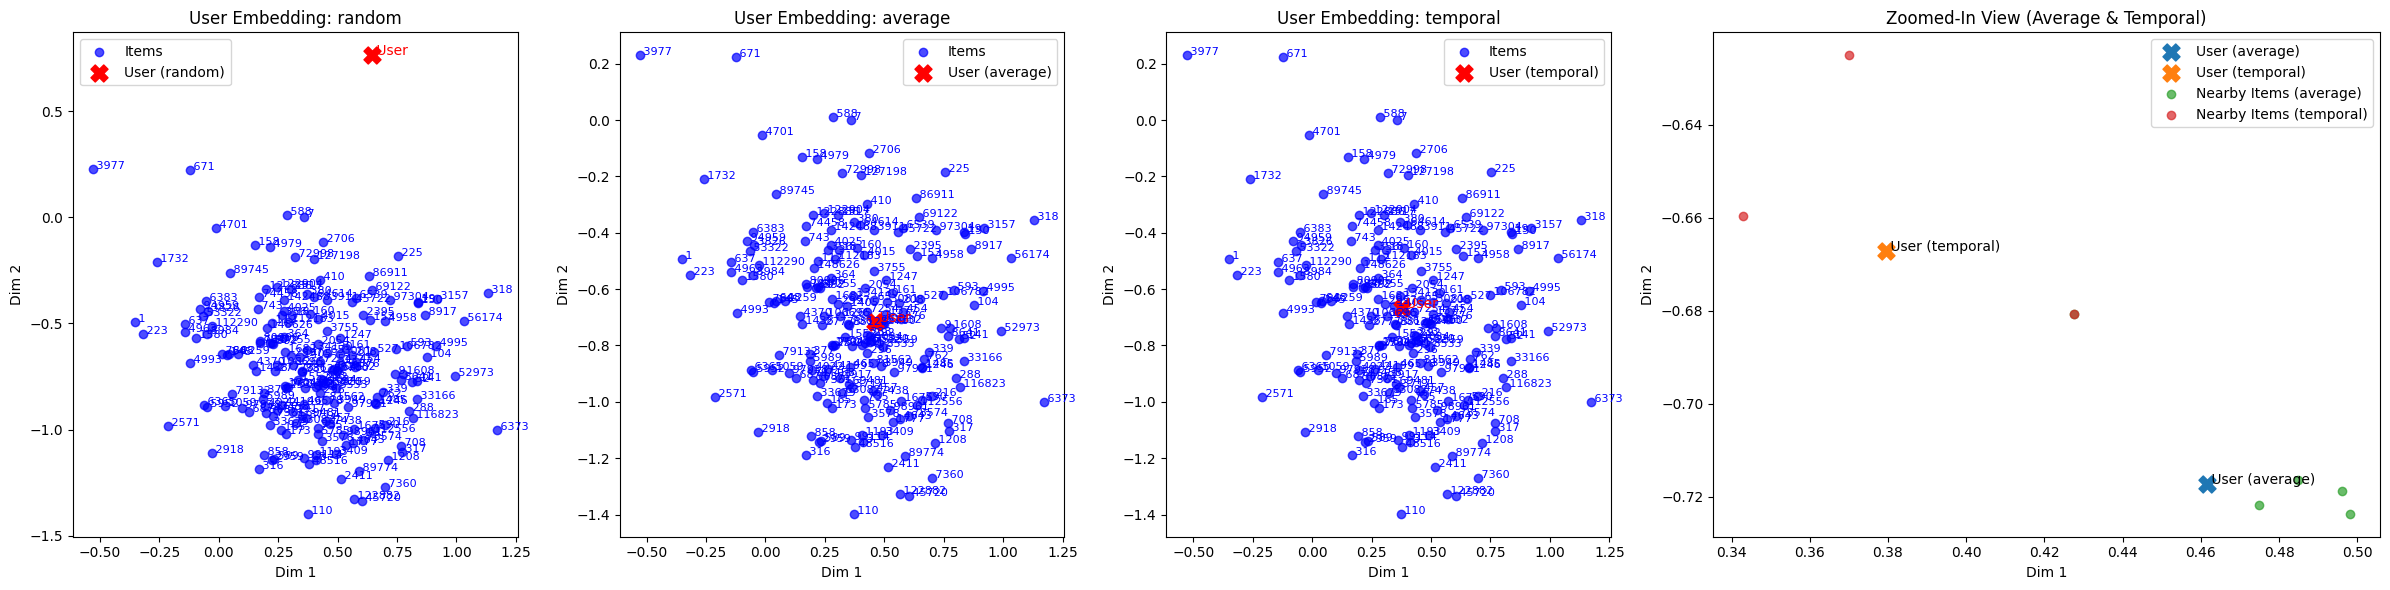

In [ ]:
##################################################
#        EXAMPLE USAGE / DEMO
##################################################
import pandas as pd

# Example: Sampling items and corresponding rows in df_ratings
def sample_data_for_demo(df_ratings, df_items, num_items=100):
    """
    Samples a subset of items and their corresponding ratings to speed up processing.

    :param df_ratings: DataFrame containing user-item interactions.
    :param df_items: DataFrame containing item metadata.
    :param num_items: Number of items to sample.
    :return: Filtered df_ratings and df_items.
    """
    # Sample a subset of items
    sampled_item_ids = df_items['itemId'].sample(num_items, random_state=42)

    # Filter df_ratings to include only rows corresponding to the sampled items
    df_ratings_sampled = df_ratings[df_ratings['itemId'].isin(sampled_item_ids)]

    # Filter df_items to include only the sampled items
    df_items_sampled = df_items[df_items['itemId'].isin(sampled_item_ids)]

    return df_ratings_sampled, df_items_sampled



def demo_user_embeddings_and_retrieval(embedding_df, df_ratings, df_items,
                                       user_ids_to_test=[1, 2],
                                       top_N_retrieval=3  # Retrieval stage
                                       ):
    """
    Demonstrates user-embedding methods (random, average, temporal), retrieves top items,
    and visualizes in 2D, with top watched movies and recommendations included.
    """
    # 1) Build the embedding_dict
    embedding_dict = build_embedding_dict(embedding_df)

    # 2) Build item matrix for retrieval
    item_matrix, item_ids = build_item_matrix(embedding_dict)

    # 3) For each user, compute embeddings with three methods
    for user_id in user_ids_to_test:
        print(f"\n=== User {user_id} ===")

        # Compute embeddings using all three methods
        emb_random = compute_user_embedding(user_id, df_ratings, embedding_dict, method="random")
        emb_average = compute_user_embedding(user_id, df_ratings, embedding_dict, method="average")
        emb_temporal = compute_user_embedding(user_id, df_ratings, embedding_dict, method="temporal")

        # Store embeddings in a dictionary
        user_embeddings_dict = {
            "random": emb_random,
            "average": emb_average,
            "temporal": emb_temporal
        }

        # Print embeddings (first 3 dimensions)
        for method, emb in user_embeddings_dict.items():
            print(f"{method.capitalize()} embedding (first 3 coords): {emb[:3]}")

        # Retrieve user's top-3 watched movies (highest-rated)
        user_ratings = df_ratings[df_ratings['userId'] == user_id].sort_values(by='rating', ascending=False)
        top_movies = user_ratings.merge(df_items, left_on='itemId', right_on='itemId').head(3)
        print("\nTop-3 User Watched Movies:")
        for _, row in top_movies.iterrows():
            print(f"  {row['title']} (Rating: {row['rating']:.1f})")

        # Retrieve top-N items for each method
        for method, emb in user_embeddings_dict.items():
            top_N_results = retrieve_top_N_items(emb, item_matrix, item_ids, N=top_N_retrieval)
            print(f"\nTop-{top_N_retrieval} Retrieval Results for {method.capitalize()} Embedding:")
            for (iid, dist) in top_N_results:
                row = df_items[df_items['itemId'] == iid]
                title = row['title'].values[0] if not row.empty else f"Item {iid}"
                print(f"  {iid} ({title}), dist={dist:.4f}")

        # Visualize in 2D (only works for first 2 dimensions)
        relevant_items = list(set(item_ids))  # Use all items for visualization
        visualize_embeddings_2d(user_embeddings_dict, embedding_dict, relevant_items)

# Suppose we already loaded embedding_df, df_ratings, df_items
# from your MovieLens pipeline:
#   embedding_df: [itemId, embeddings]
#   df_ratings: [userId, itemId, rating, timestamp]
#   df_items: [itemId, title, genres, etc.]

# Here is how you might call the demo:
# (We assume embedding_df is 3D or we won't see a 3D scatter.)

user_ids_to_test = [1, 2]
num_users_to_test = 2
# 3) Randomly sample user IDs from the dataset
all_user_ids = df_ratings['userId'].unique()
user_ids_to_test = random.sample(list(all_user_ids), min(num_users_to_test, len(all_user_ids)))
print(f"Randomly selected user IDs for testing: {user_ids_to_test}")

# 4) Sample item IDs based on the selected users
sampled_item_ids = df_ratings[df_ratings['userId'].isin(user_ids_to_test)]['itemId'].unique()
print(f"Sampled {len(sampled_item_ids)} unique item IDs based on selected users.")

# 5) Filter embedding_df and df_items for the sampled item IDs
sampled_embedding_df = embedding_df[embedding_df['itemId'].isin(sampled_item_ids)]
sampled_df_items = df_items[df_items['itemId'].isin(sampled_item_ids)]

# Pass the sampled data to your function
demo_user_embeddings_and_retrieval(sampled_embedding_df, df_ratings, df_items_sampled,
                                   user_ids_to_test,
                                   top_N_retrieval=5)


 ## 2.2 Augmentation

"Example calls to create user profiles in both manual and LLM-based ways."

In [ ]:
import openai
import pandas as pd
import numpy as np
import time

def augment_user_profile(
    user_id,
    df_ratings,
    df_items,
    method="manual",
    llm_model="gpt-4o-mini",
    api_key=None,
    top_genre_limit=5,  # Limit top genres to the most frequent 5
    top_tag_limit=15    # Limit top tags to the most frequent 15
):
    """
    Build a structured user profile for a single user, limiting the top genres
    and tags to specified numbers.

    Parameters:
    -----------
    - user_id: int
        The user we are analyzing.

    - df_ratings: pd.DataFrame
        Contains [userId, itemId, rating, timestamp] at minimum.

    - df_items: pd.DataFrame
        Contains [itemId, title, genres, tag, ...].

    - method: str, default="manual"
        - "manual": Summarize user tastes in code.
        - "llm": Summarize user tastes using LLM.

    - llm_model: str, default="gpt-4o-mini"
        The OpenAI model name to use if method="llm".

    - api_key: str or None
        The OpenAI API key. Required if method="llm".

    - top_genre_limit: int, default=5
        The number of top genres to include in the user profile.

    - top_tag_limit: int, default=15
        The number of top tags to include in the user profile.

    Returns:
    --------
    - user_profile: dict
        A structured user profile containing fields like:
        {
          "user_id": ...,
          "favorite_genres": [...],
          "favorite_tags": [...],
          "top_items": [
             { "itemId": ..., "title": "..." }, ...
          ],
          "average_rating": ...,
          "overall_taste_summary": "..."
        }
    """

    # Filter only the user’s ratings
    user_df = df_ratings[df_ratings["userId"] == user_id].copy()
    if user_df.empty:
        return {
            "user_id": user_id,
            "favorite_genres": [],
            "favorite_tags": [],
            "top_items": [],
            "average_rating": 0.0,
            "overall_taste_summary": "No data"
        }

    # Merge with item info
    user_merged = user_df.merge(df_items, on="itemId", how="left")

    # Compute average rating
    avg_rating = user_merged["rating"].mean()

    # Sort items by rating desc
    top_items = user_merged.sort_values("rating", ascending=False).head(5)

    # Collect top item info
    top_items_list = []
    for _, row in top_items.iterrows():
        top_items_list.append({
            "itemId": int(row["itemId"]),
            "title": str(row.get("title", "")),
            "rating": float(row["rating"])
        })

    # For genres
    if "genres" in user_merged.columns:
        genre_counts = {}
        for _, row in user_merged.iterrows():
            genres_str = row.get("genres", "")
            if not isinstance(genres_str, str):
                continue
            genres_list = genres_str.split("|")  # Adjust delimiter as necessary
            for g in genres_list:
                g = g.strip()
                if g:
                    genre_counts[g] = genre_counts.get(g, 0) + 1
        # Sort by frequency and limit to the top genres
        favorite_genres = sorted(genre_counts.keys(), key=lambda g: genre_counts[g], reverse=True)[:top_genre_limit]
    else:
        favorite_genres = []

    # For tags
    if "tag" in user_merged.columns:
        tag_counts = {}
        for _, row in user_merged.iterrows():
            tags_value = row.get("tag", [])
            if not isinstance(tags_value, list):
                continue
            for t in tags_value:
                t = t.strip()
                if t:
                    tag_counts[t] = tag_counts.get(t, 0) + 1
        # Sort by frequency and limit to the top tags
        favorite_tags = sorted(tag_counts.keys(), key=lambda t: tag_counts[t], reverse=True)[:top_tag_limit]
    else:
        favorite_tags = []

    # Prepare a basic "manual" summary
    if method == "manual":
        overall_taste_summary = (
            f"This user has rated {len(user_df)} items with an average rating of {avg_rating:.2f}. "
            f"The top genres seem to be {favorite_genres}. "
            f"Frequent tags: {favorite_tags}. "
            "They appear to enjoy these top 5 items: " +
            ", ".join([x["title"] for x in top_items_list]) + "."
        )
    else:
        # method == "llm"
        if api_key is None:
            raise ValueError("api_key is required for LLM-based user profile augmentation.")
        openai.api_key = api_key

        raw_text = f"""
User {user_id} has the following data:
- Average rating: {avg_rating:.2f}
- Favorite genres (by frequency): {favorite_genres}
- Favorite tags (by frequency): {favorite_tags}
- Top 5 highest rated items:
"""

        for x in top_items_list:
            raw_text += f"  - {x['title']} (rating {x['rating']:.1f})\n"

        system_msg = (
            "You are a helpful assistant that summarizes a user's taste in a short paragraph. "
            "Focus on the user's overall preferences and style, then produce a single summary string."
        )
        user_msg = (
            "Here is the raw data for a user's preferences:\n"
            f"{raw_text}\n\n"
            "Please write a concise summary of this user's overall taste. Keep it short but meaningful."
        )

        try:
            response = openai.ChatCompletion.create(
                model=llm_model,
                messages=[
                    {"role": "system", "content": system_msg},
                    {"role": "user", "content": user_msg}
                ],
                max_tokens=200,
                temperature=0.7
            )
            overall_taste_summary = response["choices"][0]["message"]["content"].strip()
        except Exception as e:
            print(f"LLM error for user {user_id}: {e}")
            overall_taste_summary = "LLM summarization failed."

    # Assemble the structured user profile
    user_profile = {
        "user_id": int(user_id),
        "favorite_genres": favorite_genres,
        "favorite_tags": favorite_tags,
        "top_items": top_items_list,
        "average_rating": float(avg_rating),
        "overall_taste_summary": overall_taste_summary
    }

    return user_profile


profile_manual = augment_user_profile(
    user_id=1,
    df_ratings=df_ratings,
    df_items=df_items,
    method="manual",
    top_genre_limit=5,  # Top 5 genres
    top_tag_limit=15    # Top 15 tags
)
display("Manual profile:", profile_manual)


profile_llm = augment_user_profile(
    user_id=1,
    df_ratings=df_ratings,
    df_items=df_items,
    method="llm",
    llm_model="gpt-4o-mini",
    api_key=os.environ.get("OPENAI_API_KEY"),
    top_genre_limit=5,  # Top 5 genres
    top_tag_limit=15    # Top 15 tags
)
display("LLM profile:", profile_llm)



'Manual profile:'

{'user_id': 1,
 'favorite_genres': ['Action', 'Comedy', 'Adventure', 'Drama', 'Thriller'],
 'favorite_tags': [],
 'top_items': [{'itemId': 5060,
   'title': 'M*A*S*H (a.k.a. MASH) (1970)',
   'rating': 5.0},
  {'itemId': 2872, 'title': 'nan', 'rating': 5.0},
  {'itemId': 1291,
   'title': 'Indiana Jones and the Last Crusade (1989)',
   'rating': 5.0},
  {'itemId': 1298, 'title': 'nan', 'rating': 5.0},
  {'itemId': 2948, 'title': 'From Russia with Love (1963)', 'rating': 5.0}],
 'average_rating': 4.366379310344827,
 'overall_taste_summary': "This user has rated 232 items with an average rating of 4.37. The top genres seem to be ['Action', 'Comedy', 'Adventure', 'Drama', 'Thriller']. Frequent tags: []. They appear to enjoy these top 5 items: M*A*S*H (a.k.a. MASH) (1970), nan, Indiana Jones and the Last Crusade (1989), nan, From Russia with Love (1963)."}

'LLM profile:'

{'user_id': 1,
 'favorite_genres': ['Action', 'Comedy', 'Adventure', 'Drama', 'Thriller'],
 'favorite_tags': [],
 'top_items': [{'itemId': 5060,
   'title': 'M*A*S*H (a.k.a. MASH) (1970)',
   'rating': 5.0},
  {'itemId': 2872, 'title': 'nan', 'rating': 5.0},
  {'itemId': 1291,
   'title': 'Indiana Jones and the Last Crusade (1989)',
   'rating': 5.0},
  {'itemId': 1298, 'title': 'nan', 'rating': 5.0},
  {'itemId': 2948, 'title': 'From Russia with Love (1963)', 'rating': 5.0}],
 'average_rating': 4.366379310344827,
 'overall_taste_summary': 'User 1 enjoys a mix of action-packed adventures and comedic moments, with a strong preference for engaging storytelling found in the genres of Action, Comedy, Adventure, Drama, and Thriller. Their top-rated items reflect a love for classic films that blend excitement and humor, achieving a high average rating of 4.37. \n\n**Summary:** User 1 favors engaging films in Action, Comedy, and Adventure, with a penchant for classics, reflected in their high

 ## 2.3 Generation Step (LLM-based final recommendation)

###"Final RAG stage: Pass a (user_profile + pre-ranked items) to GPT and parse JSON for the recommendation."

In [ ]:
!pip install inflect

In [ ]:
import json
import openai
import inflect


def method_A_generation(
    user_profile,
    ranked_item_list,
    df_items=None,
    llm_model="gpt-4o-mini",
    api_key=None,
    top_N_retrieval=50,
    top_k_rec=10,
    debug=True,
    return_prompt=False,
    chain_of_thought=False
):
    """
    Takes a user profile + a previously ranked list of items,
    asks the LLM to produce a final recommendation in JSON.

    Behavior controlled by `chain_of_thought`:
      - If chain_of_thought=True:
          The final JSON must include:
             "recommended_item_ids"
             "explanation"
             "chain_of_thought"
      - If chain_of_thought=False:
          The final JSON must ONLY have:
             "recommended_item_ids"
          (No explanation of any kind.)

    Parameters
    ----------
    user_profile : dict
        Contains fields like "user_id", "overall_taste_summary", etc.

    ranked_item_list : list
        A pre-ranked list of items, e.g. [(itemId, distance), ...]

    df_items : pd.DataFrame or None
        If provided, used to look up 'title' or other fields.

    llm_model : str, default="gpt-4o-mini"
        OpenAI model name.

    api_key : str, optional
        OpenAI API key. Required if calling the OpenAI API.

    top_k : int, default=5
        Number of items to present to the LLM as candidates.

    debug : bool, default=True
        Whether to print debug information.

    return_prompt : bool, default=False
        If True, returns the final prompt structure in the output dict.

    chain_of_thought : bool, default=False
        - If True, the LLM must return a "chain_of_thought" AND an "explanation".
        - If False, no explanation or chain-of-thought is returned at all.

    Returns
    -------
    dict
        {
            "model_output": <raw LLM text>,
            "parsed_json": { ... final JSON as a Python dict ... },
            "prompt": { ... }  # only if return_prompt=True
        }
    """

    top_N_retrieval = min(top_N_retrieval, len(ranked_item_list))

    # Create an inflect engine
    p = inflect.engine()

    # Convert the number to words
    top_k_rec_text = p.number_to_words(top_k_rec).upper()
    #print(top_k_rec_text)

    if api_key is None:
        raise ValueError("An OpenAI API key is required.")
    openai.api_key = api_key

    # 1) Slice the top-ranked items we will feed to the LLM
    top_items = ranked_item_list[:top_N_retrieval]

    # 2) Build a text snippet describing the items
    items_text = ""
    for entry in top_items:
        if isinstance(entry, tuple) and len(entry) == 2:
            item_id, score = entry
        else:
            item_id = entry
            score = None

        # Optionally fetch the title from df_items
        title_str = f"Item {item_id}"
        if df_items is not None:
            row = df_items[df_items["itemId"] == item_id]
            if not row.empty:
                title_val = row.iloc[0].get("title", "")
                if title_val:
                    title_str = title_val

        items_text += f"- ID: {item_id}, Title: {title_str}"
        if score is not None:
            items_text += f", Score: {score:.4f}"
        items_text += "\n"

    # 3) Create system & user messages,
    #    based on whether chain_of_thought is True/False.
    if chain_of_thought:
        # Prompt that REQUIRES explanation + chain_of_thought in final JSON
        system_msg = (
            "You are a helpful recommendation assistant. "
            "You have a user profile plus some candidate items. "
            f"You MUST recommend at least {top_k_rec_text} items from the provided list. "
            "Output must be valid JSON with all of these keys:\n"
            "  'recommended_item_ids': array of at least 5 item IDs\n"
            "  'explanation': a short summary\n"
            "  'chain_of_thought': your step-by-step reasoning\n"
            "For example:\n"
            "{\n"
            "  \"recommended_item_ids\": [111, 222, 333, 444, 555],\n"
            "  \"explanation\": \"short reasoning...\",\n"
            "  \"chain_of_thought\": \"step by step reasoning...\"\n"
            "}\n"
            "Make sure the JSON is valid and includes these exact keys."
        )
    else:
        # Prompt that says ONLY produce recommended_item_ids
        system_msg = (
            "You are a helpful recommendation assistant. "
            "You have a user profile plus some candidate items. "
            f"You MUST recommend at least {top_k_rec_text} items from the provided list. "
            "Output must be valid JSON with ONLY one key:\n"
            "  'recommended_item_ids': array of at least 5 item IDs\n"
            "Do NOT include any explanation or chain-of-thought.\n"
            "For example:\n"
            "{\n"
            "  \"recommended_item_ids\": [111, 222, 333, 444, 555]\n"
            "}\n"
            "Make sure the JSON is valid, with no extra keys."
        )

    user_msg = f"""
User Profile for user {user_profile.get('user_id')}:
- Favorite Genres: {user_profile.get('favorite_genres')}
- Favorite Tags: {user_profile.get('favorite_tags')}
- Average Rating: {user_profile.get('average_rating')}
- Top Items: {user_profile.get('top_items')}

Overall Taste Summary:
"{user_profile.get('overall_taste_summary')}"

Candidate items to potentially recommend (already pre-ranked):
{items_text}

Please provide your final JSON as requested above.
"""

    if debug:
        print("=== DEBUG: System Message ===")
        print(system_msg)
        print("=== DEBUG: User Message ===")
        print(user_msg)

    # Keep the prompt in case we want to return it
    prompt = {"system_message": system_msg, "user_message": user_msg}

    # 4) Call the ChatCompletion
    try:
        response = openai.ChatCompletion.create(
            model=llm_model,
            messages=[
                {"role": "system", "content": system_msg},
                {"role": "user", "content": user_msg},
            ],
            max_tokens=1000,
            temperature=0.7
        )
        model_output = response["choices"][0]["message"]["content"].strip()
    except Exception as e:
        print(f"Error calling the LLM: {e}")
        return {
            "model_output": "",
            "parsed_json": {},
            **({"prompt": prompt} if return_prompt else {})
        }

    if debug:
        print("\n=== DEBUG: Raw Model Output ===")
        print(model_output)

    # 5) Parse JSON from model output
    parsed_json = {}
    try:
        first_brace = model_output.find("{")
        last_brace = model_output.rfind("}")
        if first_brace != -1 and last_brace != -1:
            json_str = model_output[first_brace:last_brace + 1]
            parsed_json = json.loads(json_str)
    except Exception as e:
        print(f"JSON parsing error: {e}")
        parsed_json = {}

    # 6) If "recommended_item_ids" is empty or missing, fallback to top-3
    if "recommended_item_ids" not in parsed_json or not parsed_json["recommended_item_ids"]:
        fallback_item_ids = []
        for entry in top_items:
            if isinstance(entry, tuple):
                fallback_item_ids.append(entry[0])
            else:
                fallback_item_ids.append(entry)
        fallback_item_ids = fallback_item_ids[:top_k_rec]
        parsed_json["recommended_item_ids"] = fallback_item_ids

        # If chain_of_thought=True, fill them in blank if missing
        # Otherwise skip them entirely if chain_of_thought=False
        if chain_of_thought:
            if "explanation" not in parsed_json:
                parsed_json["explanation"] = "LLM did not provide an explanation."
            if "chain_of_thought" not in parsed_json:
                parsed_json["chain_of_thought"] = "LLM did not provide chain-of-thought."

    # 7) If chain_of_thought=False, ensure we do NOT leak "explanation" or "chain_of_thought"
    #    in case the model incorrectly included them.
    if not chain_of_thought:
        keys_to_remove = ["explanation", "chain_of_thought"]
        for key in keys_to_remove:
            if key in parsed_json:
                del parsed_json[key]

    # Return final result
    result = {
        "model_output": model_output,
        "parsed_json": parsed_json,
    }
    if return_prompt:
        result["prompt"] = prompt

    return result


## 2.4 End-to-End Demo Code

In [ ]:
flag_run_demo = False

top_N_retrieval = 50
top_k_rec = 10

if flag_run_demo:
  # Step 1: build embeddings ...
  # Step 2: compute user embedding ...
  # Step 3: retrieve top-N items ...
  # Step 4: build user profile ...
  # Step 5: generate final recommendation ...

  #####################################################
  # 1) Build embeddings + item matrix
  #####################################################
  print("=== STEP 1: Building Embedding Dict & Item Matrix ===")
  embedding_dict = build_embedding_dict(embedding_df)
  item_matrix, item_ids = build_item_matrix(embedding_dict)

  print(f"Number of items in embedding_dict: {len(embedding_dict)}")
  print(f"item_matrix shape: {item_matrix.shape}")


  #####################################################
  # 2) Compute the user embedding
  #####################################################
  print("\n=== STEP 2: Compute User Embedding ===")
  user_id = 3
  user_emb = compute_user_embedding(
      user_id=user_id,
      df_ratings=df_ratings,
      embedding_dict=embedding_dict,
      method="temporal",
      min_rating_threshold=4.0
  )

  print("User embedding (first 10 dimensions):", user_emb[:10])
  print("Embedding length:", len(user_emb))


  #####################################################
  # 3) Retrieve top-k items
  #####################################################
  print("\n=== STEP 3: Retrieve Top-N Items ===")
  top_N_items = retrieve_top_N_items(
      user_emb=user_emb,
      item_matrix=item_matrix,
      item_ids=item_ids,
      N=top_N_retrieval
  )

  print("Top-5 items (itemId, distance):")
  display(top_N_items)


  #####################################################
  # 4) Build user profile (Code 1)
  #####################################################
  print("\n=== STEP 4: Build User Profile ===")
  user_profile_manual = augment_user_profile(
      user_id=user_id,
      df_ratings=df_ratings,
      df_items=df_items,
      method="manual",  # or "manual",
      api_key=os.environ.get("OPENAI_API_KEY")
  )

  print("User Profile Dictionary:")
  display(user_profile_manual)


  user_profile_llm = augment_user_profile(
      user_id=user_id,
      df_ratings=df_ratings,
      df_items=df_items,
      method="llm",  # or "manual",
      api_key=os.environ.get("OPENAI_API_KEY")
  )

  print("User Profile Dictionary:")
  display(user_profile_llm)

  #####################################################
  # 5) Generate final recommendation (Code 2)
  #####################################################
  print("\n=== STEP 5: Generate Final Recommendation ===")
  recommendation_result = method_A_generation(
      user_profile=user_profile_manual,
      ranked_item_list=top_N_items,
      df_items=df_items,
      llm_model= "gpt-4o-mini",
      api_key=os.environ.get("OPENAI_API_KEY"),
      top_N_retrieval=top_N_retrieval,
      top_k_rec=top_k_rec,
      debug=True,
      return_prompt=False,
      chain_of_thought=False
  )


  print("\n=== Parsed JSON ===")
  display(recommendation_result["parsed_json"])



  print("\n=== STEP 5: Generate Final Recommendation ===")
  recommendation_result = method_A_generation(
      user_profile=user_profile_llm,
      ranked_item_list=top_N_items,
      df_items=df_items,
      llm_model= "gpt-4o-mini",
      api_key=os.environ.get("OPENAI_API_KEY"),
      top_N_retrieval=top_N_retrieval,
      top_k_rec=top_k_rec,
      debug=True,
      return_prompt=True,
      chain_of_thought=False
  )



  print("\n=== Parsed JSON ===")
  display(recommendation_result["parsed_json"])


# 3.Evaluation Workflow

##3.1. Train/Test Split by User

"Train–Test split per user: last x% as test by timestamp."

In [ ]:
###############################################################################
# 3. Evaluation Workflow
################################################################################

def train_test_split_by_user(df_ratings, timestamp_col="timestamp", test_ratio=0.3):
    """
    Splits df_ratings into train/test such that for each user,
    the last <test_ratio> fraction (sorted by timestamp) go to test.
    """
    import math

    df_train_list = []
    df_test_list = []

    grouped = df_ratings.groupby("userId")
    for user_id, group in grouped:
        group_sorted = group.sort_values(by=timestamp_col)
        n_total = len(group_sorted)
        n_test = math.ceil(n_total * test_ratio)
        if n_total <= n_test:
            # if few interactions, all or most to train (or you can handle differently)
            df_train_list.append(group_sorted)
        else:
            df_train_list.append(group_sorted.iloc[:-n_test])
            df_test_list.append(group_sorted.iloc[-n_test:])

    df_train = pd.concat(df_train_list).reset_index(drop=True)
    df_test  = pd.DataFrame()
    if df_test_list:
        df_test = pd.concat(df_test_list).reset_index(drop=True)

    return df_train, df_test

def compute_recall_at_k(pred_items, ground_truth_items, k):
    gt_set = set(ground_truth_items)
    if len(gt_set) == 0:
        return None
    pred_set = set(pred_items[:k])
    intersection = pred_set.intersection(gt_set)
    recall = len(intersection) / len(gt_set)
    return recall

def compute_ndcg_at_k(pred_items, ground_truth_items, k):
    gt_set = set(ground_truth_items)
    if len(gt_set) == 0:
        return None
    import math
    dcg = 0.0
    for i, item in enumerate(pred_items[:k], start=1):
        rel = 1 if item in gt_set else 0
        dcg += (2**rel - 1)/math.log2(i+1)
    ideal_count = min(k, len(gt_set))
    idcg = 0.0
    for i in range(1, ideal_count+1):
        idcg += (2**1 - 1)/math.log2(i+1)
    return 0 if idcg == 0 else dcg/idcg

# Example split
df_train, df_test = train_test_split_by_user(df_ratings, timestamp_col="timestamp", test_ratio=0.3)

# Build embedding dict
embedding_df = embedding_df.dropna(subset=['embeddings'])
embedding_dict = build_embedding_dict(embedding_df)
item_matrix, item_ids = build_item_matrix(embedding_dict)

train_users = set(df_train["userId"].unique())
test_users  = set(df_test["userId"].unique())
valid_users = list(train_users.intersection(test_users))

selected_user_ids = valid_users[:NUM_USERS]

TOP_N_RETRIEVAL      = 50
TOP_K_RECOMMENDATION = 10
MIN_HIGH_RATING      = 3

results = []
cnt = 0

for user_id in selected_user_ids:
    cnt += 1
    print(f"Processing user {cnt}/{len(selected_user_ids)} -> user_id={user_id}")

    user_test = df_test[df_test['userId'] == user_id]
    user_high = user_test[user_test['rating'] >= MIN_HIGH_RATING]['itemId'].tolist()

    # Compute user embeddings from the full df_ratings or from df_train only
    emb_temp = compute_user_embedding(user_id, df_ratings, embedding_dict, method="temporal")
    emb_avg  = compute_user_embedding(user_id, df_ratings, embedding_dict, method="average")

    # Retrieve top-N
    ret_temp = retrieve_top_N_items(emb_temp, item_matrix, item_ids, N=TOP_N_RETRIEVAL)
    ret_temp_ids = [x[0] for x in ret_temp]
    ret_avg  = retrieve_top_N_items(emb_avg,  item_matrix, item_ids, N=TOP_N_RETRIEVAL)
    ret_avg_ids = [x[0] for x in ret_avg]

    # Build user profile (train data)
    user_data_train = df_train[df_train["userId"] == user_id]
    user_profile_manual = augment_user_profile(user_id, df_train, df_items, method="manual", api_key=os.environ.get("OPENAI_API_KEY"))
    user_profile_llm    = augment_user_profile(user_id, df_train, df_items, method="llm", api_key=os.environ.get("OPENAI_API_KEY"))

    # Final recommendation (temporal retrieval + manual profile)
    no_reason_temp_manual = method_A_generation(
        user_profile=user_profile_manual,
        ranked_item_list=ret_temp,
        df_items=df_items,
        api_key=os.environ.get("OPENAI_API_KEY"),
        top_N_retrieval=TOP_N_RETRIEVAL,
        top_k_rec=TOP_K_RECOMMENDATION,
        debug=False,
        chain_of_thought=False
    )
    rec_no_reason_temp_manual_ids = no_reason_temp_manual["parsed_json"].get("recommended_item_ids", [])

    # Final recommendation (average retrieval + manual profile)
    no_reason_avg_manual = method_A_generation(
        user_profile=user_profile_manual,
        ranked_item_list=ret_avg,
        df_items=df_items,
        api_key=os.environ.get("OPENAI_API_KEY"),
        top_N_retrieval=TOP_N_RETRIEVAL,
        top_k_rec=TOP_K_RECOMMENDATION,
        debug=False,
        chain_of_thought=False
    )
    rec_no_reason_avg_manual_ids = no_reason_avg_manual["parsed_json"].get("recommended_item_ids", [])

    # Final recommendation (temporal retrieval + llm profile)
    no_reason_temp_llm = method_A_generation(
        user_profile=user_profile_llm,
        ranked_item_list=ret_temp,
        df_items=df_items,
        api_key=os.environ.get("OPENAI_API_KEY"),
        top_N_retrieval=TOP_N_RETRIEVAL,
        top_k_rec=TOP_K_RECOMMENDATION,
        debug=False,
        chain_of_thought=False
    )
    rec_no_reason_temp_llm_ids = no_reason_temp_llm["parsed_json"].get("recommended_item_ids", [])

    # Final recommendation (average retrieval + llm profile)
    no_reason_avg_llm = method_A_generation(
        user_profile=user_profile_llm,
        ranked_item_list=ret_avg,
        df_items=df_items,
        api_key=os.environ.get("OPENAI_API_KEY"),
        top_N_retrieval=TOP_N_RETRIEVAL,
        top_k_rec=TOP_K_RECOMMENDATION,
        debug=False,
        chain_of_thought=False
    )
    rec_no_reason_avg_llm_ids = no_reason_avg_llm["parsed_json"].get("recommended_item_ids", [])

    row = {
        "user_id": user_id,
        "user_high_rated_items": user_high,

        "retrieval_temporal": ret_temp_ids,
        "retrieval_average":  ret_avg_ids,

        "rec_no_reason_temp_manual_profile": rec_no_reason_temp_manual_ids,
        "rec_no_reason_avg_manual_profile":  rec_no_reason_avg_manual_ids,
        "rec_no_reason_temp_llm_profile":    rec_no_reason_temp_llm_ids,
        "rec_no_reason_avg_llm_profile":     rec_no_reason_avg_llm_ids
    }
    results.append(row)

df_result = pd.DataFrame(results)
print("\nEvaluation Results (head):")
display(df_result.head(5))

# Compute recall/ndcg for retrieval
K_RETRIEVAL      = TOP_N_RETRIEVAL
K_RECOMMENDATION = TOP_K_RECOMMENDATION

df_result["retrieval_temporal_recall"] = df_result.apply(
    lambda r: compute_recall_at_k(r["retrieval_temporal"], r["user_high_rated_items"], K_RETRIEVAL), axis=1
)
df_result["retrieval_temporal_ndcg"] = df_result.apply(
    lambda r: compute_ndcg_at_k(r["retrieval_temporal"], r["user_high_rated_items"], K_RETRIEVAL), axis=1
)
df_result["retrieval_average_recall"] = df_result.apply(
    lambda r: compute_recall_at_k(r["retrieval_average"], r["user_high_rated_items"], K_RETRIEVAL), axis=1
)
df_result["retrieval_average_ndcg"] = df_result.apply(
    lambda r: compute_ndcg_at_k(r["retrieval_average"], r["user_high_rated_items"], K_RETRIEVAL), axis=1
)

# Compute recall/ndcg for final recommendations
df_result["rec_no_reason_temp_manual_profile_recall"] = df_result.apply(
    lambda r: compute_recall_at_k(r["rec_no_reason_temp_manual_profile"], r["user_high_rated_items"], K_RECOMMENDATION), axis=1
)
df_result["rec_no_reason_temp_manual_profile_ndcg"] = df_result.apply(
    lambda r: compute_ndcg_at_k(r["rec_no_reason_temp_manual_profile"], r["user_high_rated_items"], K_RECOMMENDATION), axis=1
)
df_result["rec_no_reason_avg_manual_profile_recall"] = df_result.apply(
    lambda r: compute_recall_at_k(r["rec_no_reason_avg_manual_profile"], r["user_high_rated_items"], K_RECOMMENDATION), axis=1
)
df_result["rec_no_reason_avg_manual_profile_ndcg"] = df_result.apply(
    lambda r: compute_ndcg_at_k(r["rec_no_reason_avg_manual_profile"], r["user_high_rated_items"], K_RECOMMENDATION), axis=1
)
df_result["rec_no_reason_temp_llm_profile_recall"] = df_result.apply(
    lambda r: compute_recall_at_k(r["rec_no_reason_temp_llm_profile"], r["user_high_rated_items"], K_RECOMMENDATION), axis=1
)
df_result["rec_no_reason_temp_llm_profile_ndcg"] = df_result.apply(
    lambda r: compute_ndcg_at_k(r["rec_no_reason_temp_llm_profile"], r["user_high_rated_items"], K_RECOMMENDATION), axis=1
)
df_result["rec_no_reason_avg_llm_profile_recall"] = df_result.apply(
    lambda r: compute_recall_at_k(r["rec_no_reason_avg_llm_profile"], r["user_high_rated_items"], K_RECOMMENDATION), axis=1
)
df_result["rec_no_reason_avg_llm_profile_ndcg"] = df_result.apply(
    lambda r: compute_ndcg_at_k(r["rec_no_reason_avg_llm_profile"], r["user_high_rated_items"], K_RECOMMENDATION), axis=1
)

print("\nFinal df_result with metrics:")
display(df_result.head(5))

# Show average metrics
start_col = "retrieval_temporal_recall"
start_idx = list(df_result.columns).index(start_col)
selected_columns = df_result.iloc[:, start_idx+1:]
column_means = selected_columns.mean(numeric_only=True)

print("\n### Average Values Over Users ###\n")
for col, avg in column_means.items():
    print(f"{col}: {avg:.6f}")




Processing user 1/120 -> user_id=1
Processing user 2/120 -> user_id=2
Processing user 3/120 -> user_id=3
Processing user 4/120 -> user_id=4


<ipython-input-10-b87a6cb82212>:63: RuntimeWarning: overflow encountered in exp
  w = 1.0 / (1.0 + np.exp(-alpha * (t - mean_time)))


Processing user 5/120 -> user_id=5
Processing user 6/120 -> user_id=6
Processing user 7/120 -> user_id=7


<ipython-input-10-b87a6cb82212>:63: RuntimeWarning: overflow encountered in exp
  w = 1.0 / (1.0 + np.exp(-alpha * (t - mean_time)))


Processing user 8/120 -> user_id=8
Processing user 9/120 -> user_id=9
Processing user 10/120 -> user_id=10
Processing user 11/120 -> user_id=11


...

Processing user 120/120 -> user_id=120

Evaluation Results (head):


,user_id,user_high_rated_items,retrieval_temporal,retrieval_average,rec_no_reason_temp_manual_profile,rec_no_reason_avg_manual_profile,rec_no_reason_temp_llm_profile,rec_no_reason_avg_llm_profile
0,1,"[1030, 2033, 4006, 50, 608, 1617, 1089, 1213, ...","[290, 37733, 1573, 5989, 457, 4947, 82459, 416...","[5989, 290, 4161, 37733, 1573, 4947, 457, 798,...","[290, 37733, 1573, 5989, 457, 4947, 82459, 416...","[1210, 940, 1587, 2115, 1027, 37733, 1573, 380...","[290, 37733, 1573, 5989, 457, 82459, 4161, 798...","[1210, 940, 1587, 2115, 1027, 380, 165, 82459,..."
1,2,"[109487, 68157, 86345, 80906, 89774, 1704, 122...","[37733, 290, 1573, 30707, 8798, 58559, 4947, 3...","[37733, 290, 1573, 8798, 30707, 58559, 4947, 3...","[58559, 8798, 290, 1573, 30707, 5989, 457, 6, ...","[290, 8798, 30707, 457, 6, 91529, 55820, 1961,...","[58559, 8798, 6, 290, 30707, 457, 5989, 1662, ...","[58559, 37733, 290, 8798, 30707, 457, 6, 27773..."
2,3,[3024],"[5746, 3593, 1573, 6731, 290, 748, 5146, 4643,...","[5746, 3593, 6731, 1573, 290, 748, 5146, 4643,...","[5746, 6731, 3300, 2916, 1690, 122882, 7360, 2...","[5746, 6731, 5146, 3300, 2916, 122882, 1690, 2...","[5746, 6731, 2901, 122882, 2288, 2916, 3300, 7...","[5746, 6731, 7360, 122882, 2916, 2901, 1690, 4..."
3,4,"[4166, 4034, 106, 4020, 247, 1266, 937, 3996, ...","[5989, 3052, 194, 4161, 1516, 6658, 2155, 2724...","[5989, 3052, 4161, 6658, 194, 64, 1516, 1605, ...","[5989, 3052, 194, 4161, 1516, 6658, 2155, 2724...","[5989, 3052, 4161, 6658, 194, 64, 1516, 1605, ...","[194, 2724, 1961, 916, 97921, 1516, 3052, 3070...","[194, 2724, 916, 1961, 1304, 1536, 1539, 1605,..."
4,5,"[531, 589, 596, 410, 253, 36, 232, 290, 475, 5...","[194, 916, 93, 1409, 5989, 430, 3052, 203, 215...","[194, 916, 93, 5989, 1409, 430, 3052, 2155, 96...","[5989, 1961, 1271, 210, 1409, 64957, 2321, 377...","[5989, 1961, 30707, 39183, 2324, 1304, 82459, ...","[5989, 1961, 37733, 2321, 2724, 1304, 39183, 1...","[5989, 1961, 30707, 39183, 2324, 1304, 84959, ..."



Final df_result with metrics:


,user_id,user_high_rated_items,retrieval_temporal,retrieval_average,rec_no_reason_temp_manual_profile,rec_no_reason_avg_manual_profile,rec_no_reason_temp_llm_profile,rec_no_reason_avg_llm_profile,retrieval_temporal_recall,retrieval_temporal_ndcg,retrieval_average_recall,retrieval_average_ndcg,rec_no_reason_temp_manual_profile_recall,rec_no_reason_temp_manual_profile_ndcg,rec_no_reason_avg_manual_profile_recall,rec_no_reason_avg_manual_profile_ndcg,rec_no_reason_temp_llm_profile_recall,rec_no_reason_temp_llm_profile_ndcg,rec_no_reason_avg_llm_profile_recall,rec_no_reason_avg_llm_profile_ndcg
0,1,"[1030, 2033, 4006, 50, 608, 1617, 1089, 1213, ...","[290, 37733, 1573, 5989, 457, 4947, 82459, 416...","[5989, 290, 4161, 37733, 1573, 4947, 457, 798,...","[290, 37733, 1573, 5989, 457, 4947, 82459, 416...","[1210, 940, 1587, 2115, 1027, 37733, 1573, 380...","[290, 37733, 1573, 5989, 457, 82459, 4161, 798...","[1210, 940, 1587, 2115, 1027, 380, 165, 82459,...",0.045455,0.049097,0.030303,0.029999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,"[109487, 68157, 86345, 80906, 89774, 1704, 122...","[37733, 290, 1573, 30707, 8798, 58559, 4947, 3...","[37733, 290, 1573, 8798, 30707, 58559, 4947, 3...","[58559, 8798, 290, 1573, 30707, 5989, 457, 6, ...","[290, 8798, 30707, 457, 6, 91529, 55820, 1961,...","[58559, 8798, 6, 290, 30707, 457, 5989, 1662, ...","[58559, 37733, 290, 8798, 30707, 457, 6, 27773...",0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,[3024],"[5746, 3593, 1573, 6731, 290, 748, 5146, 4643,...","[5746, 3593, 6731, 1573, 290, 748, 5146, 4643,...","[5746, 6731, 3300, 2916, 1690, 122882, 7360, 2...","[5746, 6731, 5146, 3300, 2916, 122882, 1690, 2...","[5746, 6731, 2901, 122882, 2288, 2916, 3300, 7...","[5746, 6731, 7360, 122882, 2916, 2901, 1690, 4...",0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,"[4166, 4034, 106, 4020, 247, 1266, 937, 3996, ...","[5989, 3052, 194, 4161, 1516, 6658, 2155, 2724...","[5989, 3052, 4161, 6658, 194, 64, 1516, 1605, ...","[5989, 3052, 194, 4161, 1516, 6658, 2155, 2724...","[5989, 3052, 4161, 6658, 194, 64, 1516, 1605, ...","[194, 2724, 1961, 916, 97921, 1516, 3052, 3070...","[194, 2724, 916, 1961, 1304, 1536, 1539, 1605,...",0.000000,0.000000,0.020408,0.014486,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,"[531, 589, 596, 410, 253, 36, 232, 290, 475, 5...","[194, 916, 93, 1409, 5989, 430, 3052, 203, 215...","[194, 916, 93, 5989, 1409, 430, 3052, 2155, 96...","[5989, 1961, 1271, 210, 1409, 64957, 2321, 377...","[5989, 1961, 30707, 39183, 2324, 1304, 82459, ...","[5989, 1961, 37733, 2321, 2724, 1304, 39183, 1...","[5989, 1961, 30707, 39183, 2324, 1304, 84959, ...",0.153846,0.067846,0.153846,0.068629,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



### Average Values Over Users ###

retrieval_temporal_ndcg: 0.096862
retrieval_average_recall: 0.070260
retrieval_average_ndcg: 0.055245
rec_no_reason_temp_manual_profile_recall: 0.036694
rec_no_reason_temp_manual_profile_ndcg: 0.088236
rec_no_reason_avg_manual_profile_recall: 0.032368
rec_no_reason_avg_manual_profile_ndcg: 0.061562
rec_no_reason_temp_llm_profile_recall: 0.038098
rec_no_reason_temp_llm_profile_ndcg: 0.094785
rec_no_reason_avg_llm_profile_recall: 0.033431
rec_no_reason_avg_llm_profile_ndcg: 0.068729


In [ ]:
# Provide links to download files in Google Colab
import google.colab.files

# Save DataFrame as CSV
df_path = f"/content/recResults_ds_name_{ds_name}_NUM_USERS_{NUM_USERS}_attack_scenario_{selected_embedding_column}_attackName_{attackName}_attack_direction_{attack_direction}.csv"
df_result.to_csv(df_path, index=False)

# Save list as CSV
list_path = f"/content/attackIds_ds_name_{ds_name}_{selected_embedding_column}.csv"
pd.DataFrame({"itemId": attacked_item_ids_list}).to_csv(list_path, index=False)

# Confirm file saved correctly by displaying its content
list_df = pd.read_csv(list_path)

# Download both files
google.colab.files.download(df_path)
google.colab.files.download(list_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_result.head(30)

,user_id,user_high_rated_items,retrieval_temporal,retrieval_average,rec_no_reason_temp_manual_profile,rec_no_reason_avg_manual_profile,rec_no_reason_temp_llm_profile,rec_no_reason_avg_llm_profile,retrieval_temporal_recall,retrieval_temporal_ndcg,retrieval_average_recall,retrieval_average_ndcg,rec_no_reason_temp_manual_profile_recall,rec_no_reason_temp_manual_profile_ndcg,rec_no_reason_avg_manual_profile_recall,rec_no_reason_avg_manual_profile_ndcg,rec_no_reason_temp_llm_profile_recall,rec_no_reason_temp_llm_profile_ndcg,rec_no_reason_avg_llm_profile_recall,rec_no_reason_avg_llm_profile_ndcg
0,1,"[1030, 2033, 4006, 50, 608, 1617, 1089, 1213, ...","[290, 37733, 1573, 5989, 457, 4947, 82459, 416...","[5989, 290, 4161, 37733, 1573, 4947, 457, 798,...","[290, 37733, 1573, 5989, 457, 4947, 82459, 416...","[1210, 940, 1587, 2115, 1027, 37733, 1573, 380...","[290, 37733, 1573, 5989, 457, 82459, 4161, 798...","[1210, 940, 1587, 2115, 1027, 380, 165, 82459,...",0.045455,0.049097,0.030303,0.029999,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,"[109487, 68157, 86345, 80906, 89774, 1704, 122...","[37733, 290, 1573, 30707, 8798, 58559, 4947, 3...","[37733, 290, 1573, 8798, 30707, 58559, 4947, 3...","[58559, 8798, 290, 1573, 30707, 5989, 457, 6, ...","[290, 8798, 30707, 457, 6, 91529, 55820, 1961,...","[58559, 8798, 6, 290, 30707, 457, 5989, 1662, ...","[58559, 37733, 290, 8798, 30707, 457, 6, 27773...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3,[3024],"[5746, 3593, 1573, 6731, 290, 748, 5146, 4643,...","[5746, 3593, 6731, 1573, 290, 748, 5146, 4643,...","[5746, 6731, 3300, 2916, 1690, 122882, 7360, 2...","[5746, 6731, 5146, 3300, 2916, 122882, 1690, 2...","[5746, 6731, 2901, 122882, 2288, 2916, 3300, 7...","[5746, 6731, 7360, 122882, 2916, 2901, 1690, 4...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,4,"[4166, 4034, 106, 4020, 247, 1266, 937, 3996, ...","[5989, 3052, 194, 4161, 1516, 6658, 2155, 2724...","[5989, 3052, 4161, 6658, 194, 64, 1516, 1605, ...","[5989, 3052, 194, 4161, 1516, 6658, 2155, 2724...","[5989, 3052, 4161, 6658, 194, 64, 1516, 1605, ...","[194, 2724, 1961, 916, 97921, 1516, 3052, 3070...","[194, 2724, 916, 1961, 1304, 1536, 1539, 1605,...",0.000000,0.000000,0.020408,0.014486,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,5,"[531, 589, 596, 410, 253, 36, 232, 290, 475, 5...","[194, 916, 93, 1409, 5989, 430, 3052, 203, 215...","[194, 916, 93, 5989, 1409, 430, 3052, 2155, 96...","[5989, 1961, 1271, 210, 1409, 64957, 2321, 377...","[5989, 1961, 30707, 39183, 2324, 1304, 82459, ...","[5989, 1961, 37733, 2321, 2724, 1304, 39183, 1...","[5989, 1961, 30707, 39183, 2324, 1304, 84959, ...",0.153846,0.067846,0.153846,0.068629,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,6,"[628, 347, 87, 505, 711, 76, 126, 609, 667, 56...","[5989, 3052, 194, 430, 4161, 64, 93, 1961, 154...","[5989, 194, 3052, 93, 4161, 430, 1961, 64, 307...","[3052, 30707, 1271, 339, 1961, 430, 350, 82459...","[5989, 194, 3052, 93, 4161, 1961, 30707, 1541,...","[194, 1961, 30707, 97921, 339, 1271, 351, 430,...","[30707, 1961, 290, 97921, 64, 351, 375, 350, 2...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,7,"[7445, 27741, 8665, 8958, 8949, 30812, 2671, 3...","[2671, 1541, 1755, 5989, 64, 4161, 2724, 380, ...","[290, 798, 1573, 5989, 457, 165, 37733, 1633, ...","[5989, 380, 49272, 125914, 33679, 5872, 45501,...","[1573, 165, 8636, 380, 2115, 3994, 1527, 58559...","[380, 49272, 5872, 33679, 97921, 1541, 1755, 5...","[165, 8636, 380, 2115, 1527, 44191, 5989, 1021...",0.080000,0.158522,0.040000,0.025580,0.040000,0.110046,0.040000,0.078398,0.040000,0.138862,0.040000,0.066254
7,8,"[586, 539, 527, 597, 440, 357, 282, 236, 11, 2...","[5989, 37733, 1633, 194, 457, 1961, 448, 3052,...","[5989,

In [ ]:
import math
import numpy as np
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

def compute_recall_at_k(pred_items, ground_truth_items, k):
    """
    Recall@K = (# relevant in top-K) / (total # relevant).
    Returns None if ground_truth_items is empty.
    """
    if not ground_truth_items:
        return None
    gt_set = set(ground_truth_items)
    top_k_items = pred_items[:k]
    overlap = gt_set.intersection(top_k_items)
    return len(overlap) / len(gt_set)

def compute_ndcg_at_k(pred_items, ground_truth_items, k):
    """
    NDCG@K for binary relevance.
    Returns None if ground_truth_items is empty.
    """
    if not ground_truth_items:
        return None

    gt_set = set(ground_truth_items)
    dcg = 0.0
    for i, item in enumerate(pred_items[:k], start=1):
        rel = 1 if item in gt_set else 0
        dcg += (2**rel - 1) / math.log2(i+1)

    ideal_count = min(k, len(gt_set))
    idcg = 0.0
    for i in range(1, ideal_count+1):
        idcg += (2**1 - 1) / math.log2(i+1)

    return 0.0 if idcg == 0 else dcg / idcg

def get_rank_position_dict(rec_list):
    """
    Given a list of item IDs in recommended order,
    return a dict: {itemId: rank_position (1-based)}.
    """
    return {item_id: idx+1 for idx, item_id in enumerate(rec_list)}

def collect_attacked_positions(df_result, attacked_item_ids, approach_col, top_k=10):
    """
    For each user, look up the recommended list in column `approach_col`.
    Return a list of (user_id, attacked_item_id, rank_position or None).
    """
    records = []
    for _, row in df_result.iterrows():
        user_id = row["user_id"]

        # parse the recommendation column (which might be a Python list or a stringified list)
        rec_list = row[approach_col]
        if isinstance(rec_list, str):
            rec_list = ast.literal_eval(rec_list)

        rank_dict = get_rank_position_dict(rec_list)

        for aitem in attacked_item_ids:
            rpos = rank_dict.get(aitem, None)
            records.append({
                "user_id": user_id,
                "approach": approach_col,
                "attacked_item_id": aitem,
                "rank_position": rpos
            })
    return pd.DataFrame(records)

def evaluate_approach(df_result, attacked_item_ids, approach_col, top_k=10):
    """
    Compute:
    1) recall@K, ndcg@K   over all users
    2) average rank for attacked items
    3) fraction of attacked items in top-K (AttackedTopKRate)
    """
    # 1) Gather user-level recall/ndcg
    recalls = []
    ndcgs = []

    for _, row in df_result.iterrows():
        # ground_truth might be in "user_high_rated_items" or similar
        ground_truth = row["user_high_rated_items"]
        if isinstance(ground_truth, str):
            ground_truth = ast.literal_eval(ground_truth)

        rec_list = row[approach_col]
        if isinstance(rec_list, str):
            rec_list = ast.literal_eval(rec_list)

        r = compute_recall_at_k(rec_list, ground_truth, top_k)
        n = compute_ndcg_at_k(rec_list, ground_truth, top_k)
        if r is not None: recalls.append(r)
        if n is not None: ndcgs.append(n)

    recall_avg = np.mean(recalls) if recalls else None
    ndcg_avg   = np.mean(ndcgs)   if ndcgs   else None

    # 2) Attacked item rank positions
    df_positions = collect_attacked_positions(df_result, attacked_item_ids, approach_col, top_k)
    df_positions_used = df_positions.dropna(subset=["rank_position"])
    avg_rank = df_positions_used["rank_position"].mean() if len(df_positions_used) > 0 else None

    # 3) AttackedTopKRate
    # total = number of (user, attacked_item) pairs
    # in_topk = those pairs with rank_position <= top_k
    total_attacks = len(df_positions)
    in_topk = df_positions_used[df_positions_used["rank_position"] <= top_k]
    attacked_topk_rate = len(in_topk) / total_attacks if total_attacks > 0 else 0.0

    return {
        "approach": approach_col,
        "Recall@K": recall_avg,
        "NDCG@K": ndcg_avg,
        "AvgRank(Attacked)": avg_rank,
        "AttackedTopKRate": attacked_topk_rate
    }

def evaluate_scenario(df_result, attacked_item_ids, approach_cols, top_k=10):
    """
    Evaluate multiple approaches (columns) and return a DataFrame summary.
    """
    rows = []
    for approach_col in approach_cols:
        row = evaluate_approach(df_result, attacked_item_ids, approach_col, top_k=top_k)
        rows.append(row)
    return pd.DataFrame(rows)

def plot_attacked_rank_distribution(df_result, attacked_item_ids, approach_cols, top_k=10):
    """
    Create a single figure with a smooth (KDE) distribution of attacked-item ranks
    for each approach. Optionally remove bar backgrounds by using `kdeplot`.
    """
    # Collect rank_position data for each approach
    df_list = []
    for approach_col in approach_cols:
        df_pos = collect_attacked_positions(df_result, attacked_item_ids, approach_col, top_k=None)  # no top_k cutoff
        df_pos["approach"] = approach_col
        df_list.append(df_pos)
    df_all = pd.concat(df_list, ignore_index=True)

    # Drop rows where the attacked item didn't appear at all (rank_position = None)
    df_all = df_all.dropna(subset=["rank_position"])

    # Plot: Using seaborn kdeplot or histplot with `kde=True`
    plt.figure(figsize=(9, 6))

    # If you want separate lines per approach:
    for approach_col in approach_cols:
        subset = df_all[df_all["approach"] == approach_col]
        sns.kdeplot(
            data=subset,
            x="rank_position",
            label=approach_col,
            fill=False,  # set True if you want the area under the curve filled
            bw_adjust=0.7  # smoothing factor, adjust as needed
        )

    plt.title("Distribution of Attacked Items' Ranks (Smooth KDE)")
    plt.xlabel("Rank Position")
    plt.ylabel("Density")
    plt.legend()
    plt.show()



=== Retrieval-Stage Evaluation ===


,approach,Recall@K,NDCG@K,AvgRank(Attacked),AttackedTopKRate
0,retrieval_temporal,0.036503,0.094275,25.341463,0.008114
1,retrieval_average,0.019089,0.042659,24.946860,0.006360



=== Recommendation-Stage Evaluation ===


,approach,Recall@K,NDCG@K,AvgRank(Attacked),AttackedTopKRate
0,rec_no_reason_temp_manual_profile,0.036694,0.088236,6.565217,0.005044
1,rec_no_reason_avg_manual_profile,0.032368,0.061562,6.608696,0.005044
2,rec_no_reason_temp_llm_profile,0.038098,0.094785,6.050000,0.004167
3,rec_no_reason_avg_llm_profile,0.033431,0.068729,6.777778,0.003947


Plotting rank distributions...


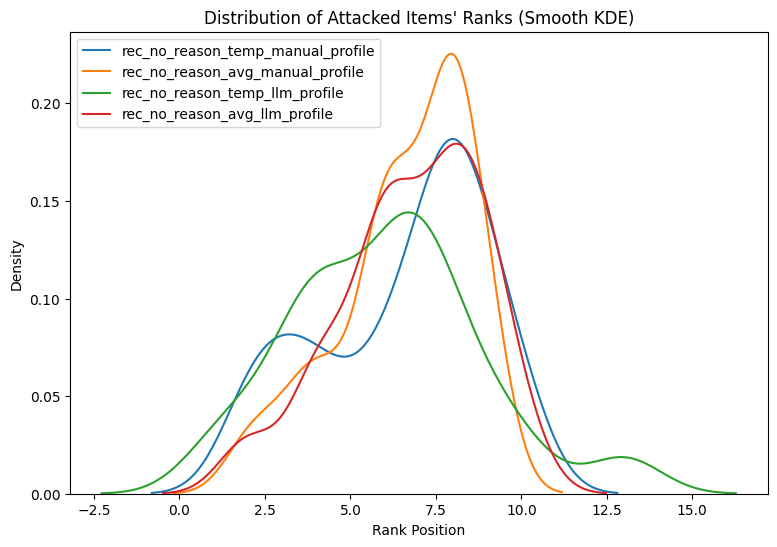

In [ ]:
###########################################
# EXAMPLE USAGE
###########################################

# Suppose df_result and your attacked_item_ids_list exist:
#  - attacked_item_ids_list: array/list of itemIds that were poisoned.

# 1) Choose which approaches (columns) to evaluate.
retrieval_columns = ["retrieval_temporal", "retrieval_average"]
recommendation_columns = [
    "rec_no_reason_temp_manual_profile",
    "rec_no_reason_avg_manual_profile",
    "rec_no_reason_temp_llm_profile",
    "rec_no_reason_avg_llm_profile"
]

# 2) Evaluate retrieval scenario
df_eval_retrieval = evaluate_scenario(
    df_result=df_result,
    attacked_item_ids=attacked_item_ids_list,
    approach_cols=retrieval_columns,
    top_k=10
)
print("\n=== Retrieval-Stage Evaluation ===")
display(df_eval_retrieval)

# 3) Evaluate final recommendation scenario
df_eval_recommendation = evaluate_scenario(
    df_result=df_result,
    attacked_item_ids=attacked_item_ids_list,
    approach_cols=recommendation_columns,
    top_k=10
)
print("\n=== Recommendation-Stage Evaluation ===")
display(df_eval_recommendation)

# 4) Plot the distribution of attacked items' ranks in a smooth KDE:
print("Plotting rank distributions...")
plot_attacked_rank_distribution(
    df_result=df_result,
    attacked_item_ids=attacked_item_ids_list,
    approach_cols=recommendation_columns,
    top_k=50  # you can pick a large top_k or None so you see ranks beyond 10
)
